# Comparing Power Spectra for Different Flamingo Simulations

In [1]:
#Bring in the necessary machinery

from fitting_machinery import *

In [72]:
%%capture
%run 'fitting_machinery.ipynb'

## Custom Comparison

In [3]:
#Select desired simulations, spectra and biases. Bias plots give parameters constrained by both mp and pp. 

In [71]:
# picks = selectinator(feedback, cosmology, spectra, biases)

Text(value='', description='Redshifts', placeholder='Type something')

Button(button_style='success', description='Confirm', style=ButtonStyle())

Output()

## Feedback Variations

### L1_m9

In [32]:
# Set a base snapshot
snpk = SnapPk('L1_m9', 67, kmax=10)
# Create a cosmology object with the same parameters as Flamingo
cosmo = ccl.Cosmology(h=0.681, Omega_b=0.0486, Omega_c=0.306-0.0486, n_s=0.967, sigma8=0.807)

# Initialise the Eulerian PT calculator.
# Check out the documentation in https://ccl.readthedocs.io/en/latest/api/pyccl.nl_pt.ept.html
# to see the meaning of all parameters.
# We may want to play around with e.g. b1_pk_kind and sub_lowk, for example.
ept = ccl.nl_pt.EulerianPTCalculator(with_NC=True, sub_lowk=False, b1_pk_kind='pt', bk2_pk_kind='linear')
ept.update_ingredients(cosmo)

# Generate power spectrum interpolators for the different
# EFT templates.
pairs = ['b1:b1', 'b1:b2', 'b1:bs', 'b1:bk2', 'b2:b2', 'b2:bs', 'bs:bs']
pk2d_templates = {pair: ept.get_pk2d_template(pair) for pair in pairs}

#### Fitting Matter-Pressure

Fit results: b1=1.232e-04, b2=-4.584e-04, bs=-1.981e-03, bk2=-1.839e-03, N=6.324e-01, chi2/ndof=1.04, ndof = 8.100e+01
Fit results: b1=1.232e-04, b2=-4.584e-04, bs=-1.981e-03, bk2=-1.839e-03, N=6.324e-01, chi2/ndof=1.04, ndof = 8.100e+01


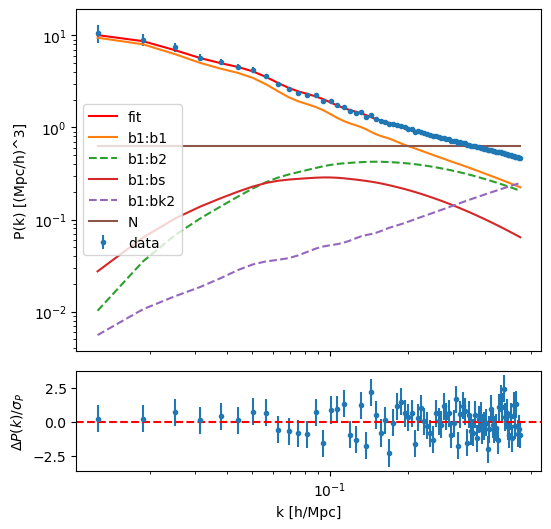

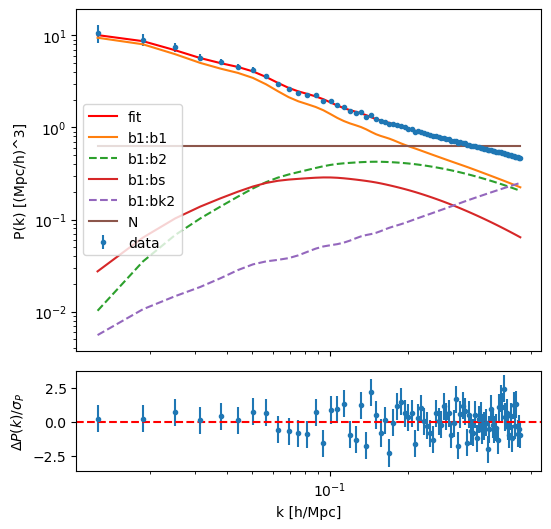

In [12]:
snpk = SnapPk('L1_m9', 122, kmax=10)
b_bf_ana, b_cov_ana = fit_pk_analytic(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.55, kmin=0.01)[:2]
b_bf, b_cov = fit_pk(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.55, kmin=0.01)[:2]

/tmp/ipykernel_58088/3266106401.py:36: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((pk11*pk22+pk12**2)/nk)


Fit results: b1=3.276e-11, b2=2.191e-09, bs=-8.424e-09, bk2=-4.782e-10, N=1.822e-11, chi2/ndof=1.06, ndof = 8.500e+01
Fit results: b1=3.276e-11, b2=2.192e-09, bs=-8.420e-09, bk2=-4.782e-10, N=1.822e-11, chi2/ndof=1.06, ndof = 8.500e+01


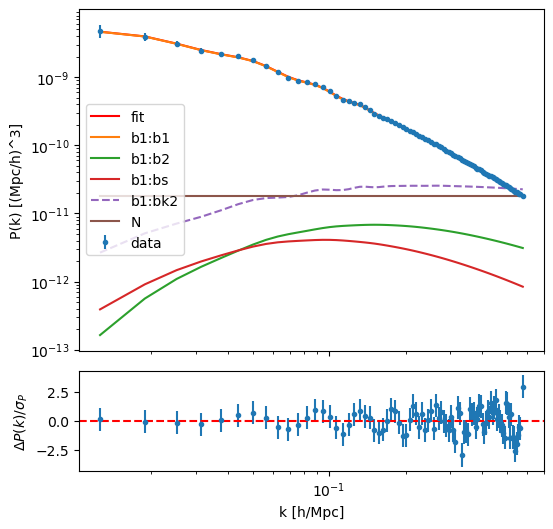

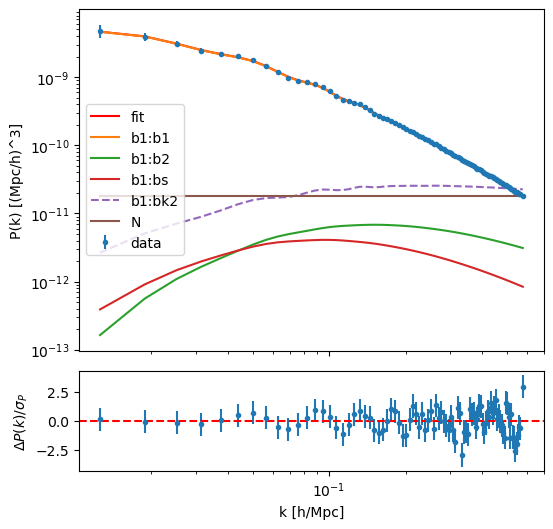

In [18]:
snpk = SnapPk('L1_m9', 1, kmax=10)
b_bf_ana, b_cov_ana = fit_pk_analytic(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.60, kmin=0.01)[:2]
b_bf, b_cov = fit_pk(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.60, kmin=0.01)[:2]

#### Fitting Pressure-Pressure

/tmp/ipykernel_47781/3266106401.py:36: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((pk11*pk22+pk12**2)/nk)


Fit results: b1=4.184e-11, b2=-9.372e-11, bs=1.109e-10, bk2=2.501e-11, N=-1.193e-22, chi2/ndof=0.95
[ 4.18353503e-11 -9.37238277e-11  1.10936805e-10  2.50105628e-11
 -1.19280083e-22]


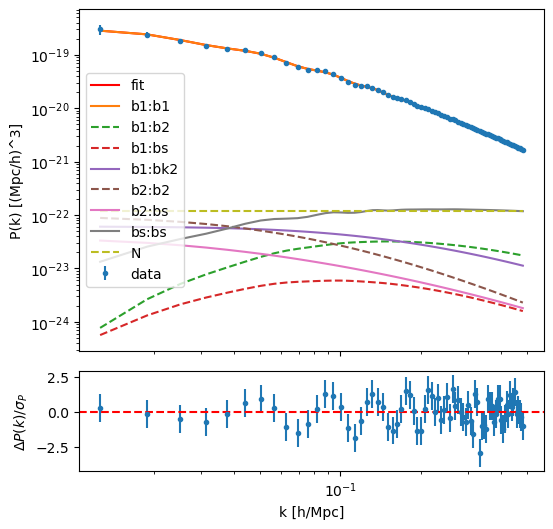

In [215]:
snpk = SnapPk('L1_m9', 3, kmax=10)
b_bf, b_cov = fit_pk(snpk, snpk.pks['pressure_pressure'], snpk.epks['pressure_pressure'], kmax=0.49, kmin=0.01, nl = True)[:2]

#### Finding acceptable kmax

In [212]:
snaps = [SnapPk('L1_m9', sn, kmax=10) for sn in range(0,120)]  

/tmp/ipykernel_47781/3266106401.py:36: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((pk11*pk22+pk12**2)/nk)


In [199]:
k_break_mp = find_breakdown(snpk, np.geomspace(0.1, 1.0, 30), 'matter_pressure')
print(f'Breakdown at kmax = {k_break:.2f}' if k_break else 'No breakdown found')

Breakdown at kmax = 0.58


In [200]:
k_break_pp = find_breakdown(snpk, np.geomspace(0.1, 1.0, 30), 'pressure_pressure')
print(f'Breakdown at kmax = {k_break:.2f}' if k_break else 'No breakdown found')

Breakdown at kmax = 0.58


In [71]:
np.set_printoptions(legacy='1.25')
snaps = [SnapPk('L1_m9', sn, kmax=10) for sn in range(0,123)]  
for sn in snaps:
    k_break_mp = find_breakdown(sn, np.linspace(0.1, 0.8, 50), 'matter_pressure')
    print(f'Redshift = {sn.z}', f'{k_break_mp[:3]}', sep='\n')

/tmp/ipykernel_58088/3266106401.py:36: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((pk11*pk22+pk12**2)/nk)


Redshift = 30.0
((0.6142857142857143, 2.3442723320574914), (0.6285714285714286, 2.8536088123190932), (0.6428571428571429, 2.8536088123190932))
Redshift = 29.0
((0.6142857142857143, 2.2721895725128), (0.6285714285714286, 2.7707849466407546), (0.6428571428571429, 2.7707849466407546))
Redshift = 28.0
((0.6142857142857143, 2.211149016201641), (0.6285714285714286, 2.7020123081498646), (0.6428571428571429, 2.7020123081498646))
Redshift = 27.0
((0.6142857142857143, 2.1558499012591743), (0.6285714285714286, 2.6400734404793633), (0.6428571428571429, 2.6400734404793633))
Redshift = 26.0
((0.6142857142857143, 2.094452359710885), (0.6285714285714286, 2.5701769902932403), (0.6428571428571429, 2.5701769902932403))
Redshift = 25.0
((0.6142857142857143, 2.031902681825849), (0.6285714285714286, 2.500952248038163), (0.6428571428571429, 2.500952248038163))
Redshift = 24.0
((0.6142857142857143, 1.9701491840643093), (0.6285714285714286, 2.4362118009412868), (0.6428571428571429, 2.4362118009412868))
Redshif

There's not much variation in breakdown scale?

In [80]:
np.set_printoptions(legacy='1.25')
snaps = [SnapPk('L1_m9', sn, kmax=10) for sn in range(0,123)]  
for sn in snaps:
    k_break_pp = find_breakdown_nl(sn, np.linspace(0.1, 0.8, 50), 'pressure_pressure')
    print(f'Redshift = {sn.z}', f'{k_break_pp[:3]}', sep='\n')

/tmp/ipykernel_58088/3266106401.py:36: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((pk11*pk22+pk12**2)/nk)


Redshift = 30.0
((0.37142857142857144, 1.199855278266649), (0.4, 1.1914797107627526), (0.5857142857142857, 1.3132898798257335))
Redshift = 29.0
((0.5857142857142857, 1.265031470988071), (0.6, 1.265031470988071), (0.6142857142857143, 2.4557954227249996))
Redshift = 28.0
((0.5857142857142857, 1.227244129516644), (0.6, 1.227244129516644), (0.6142857142857143, 2.40237250771254))
Redshift = 27.0
((0.5857142857142857, 1.1946464011420321), (0.6, 1.1946464011420321), (0.6142857142857143, 2.355890950479811))
Redshift = 26.0
((0.5857142857142857, 1.1631030706503598), (0.6, 1.1631030706503598), (0.6142857142857143, 2.294922825256463))
Redshift = 25.0
((0.6142857142857143, 2.229178008994452), (0.6285714285714286, 2.47631711327408), (0.6428571428571429, 2.47631711327408))
Redshift = 24.0
((0.6142857142857143, 2.164983685525357), (0.6285714285714286, 2.421847092334841), (0.6428571428571429, 2.421847092334841))
Redshift = 23.0
((0.6142857142857143, 2.1019395054581307), (0.6285714285714286, 2.36834166

In [77]:
snpk = SnapPk('L1_m9', 1, kmax=10)
fit_pk(snpk, snpk.pks['pressure_pressure'], snpk.epks['pressure_pressure'], kmax=0.8, kmin=0.1, verbose=False, plot=False, nl = True)

/tmp/ipykernel_58088/3266106401.py:36: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((pk11*pk22+pk12**2)/nk)


(array([ 3.29804598e-11, -5.94057356e-11,  9.67422396e-11,  2.44876220e-11,
        -6.94190371e-23]),
 array([[ 1.22665471e-24, -9.20143767e-20,  4.23134869e-19,
         -1.70788445e-22,  3.20554892e-34],
        [-9.20143767e-20,  1.22431479e-14, -5.36599927e-14,
          1.42294502e-17, -2.72125743e-29],
        [ 4.23134869e-19, -5.36599927e-14,  2.35928057e-13,
         -6.47376879e-17,  1.23561978e-28],
        [-1.70788445e-22,  1.42294502e-17, -6.47376879e-17,
          2.41742081e-20, -4.55160746e-32],
        [ 3.20554892e-34, -2.72125743e-29,  1.23561978e-28,
         -4.55160746e-32,  8.58092612e-44]]),
 3.5245578181269237,
 0.15911145683514602)

#### Comparing Fits at different redshifts

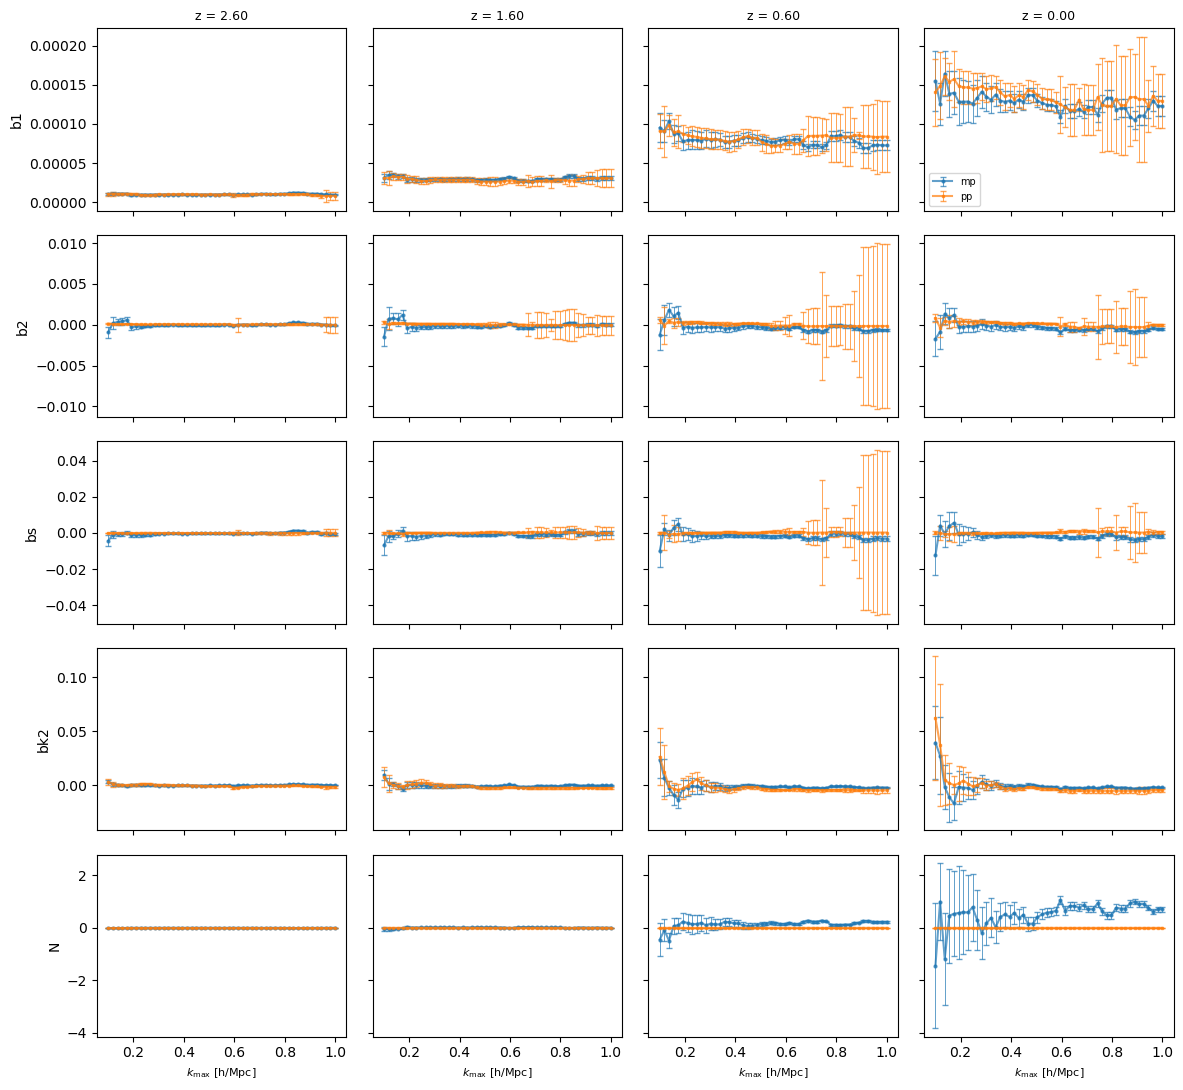

In [134]:
snaps = [SnapPk('L1_m9', sn, kmax=10) for sn in [70, 90, 110, 122]]  
grid_bias_plots(snaps, kmaxes);

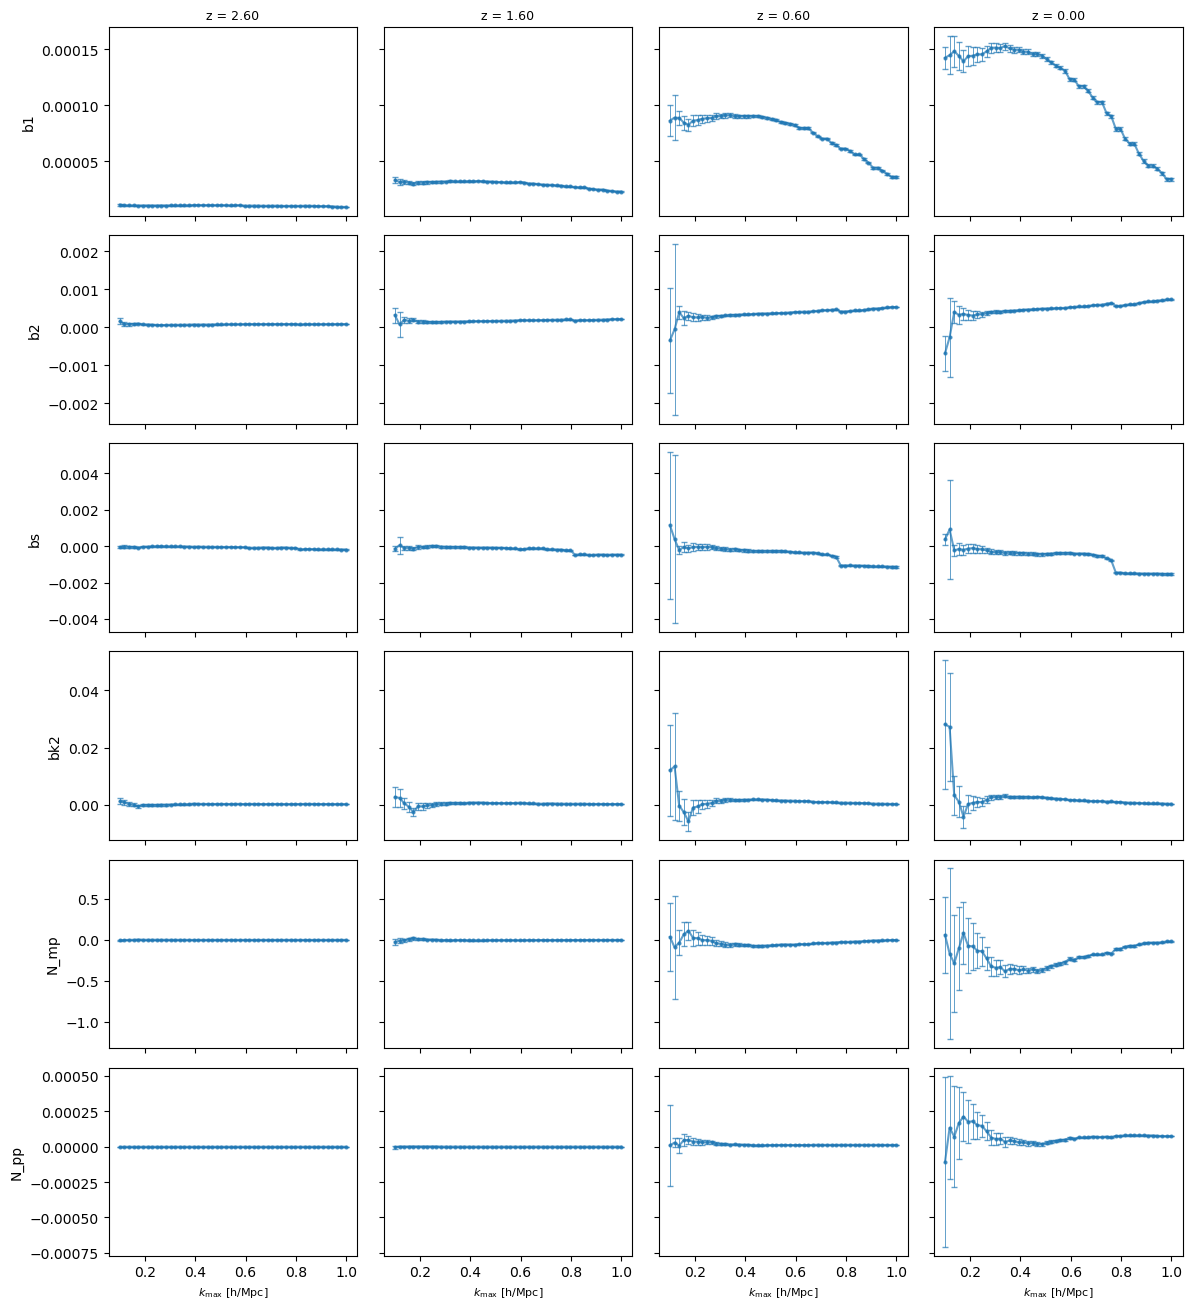

In [135]:
tks  = [templates_by_cosmo[sim_cosmology['L1_m9']]] * len(snaps)  
fig = grid_joint_bias_plots(snaps, tks, kmaxes)

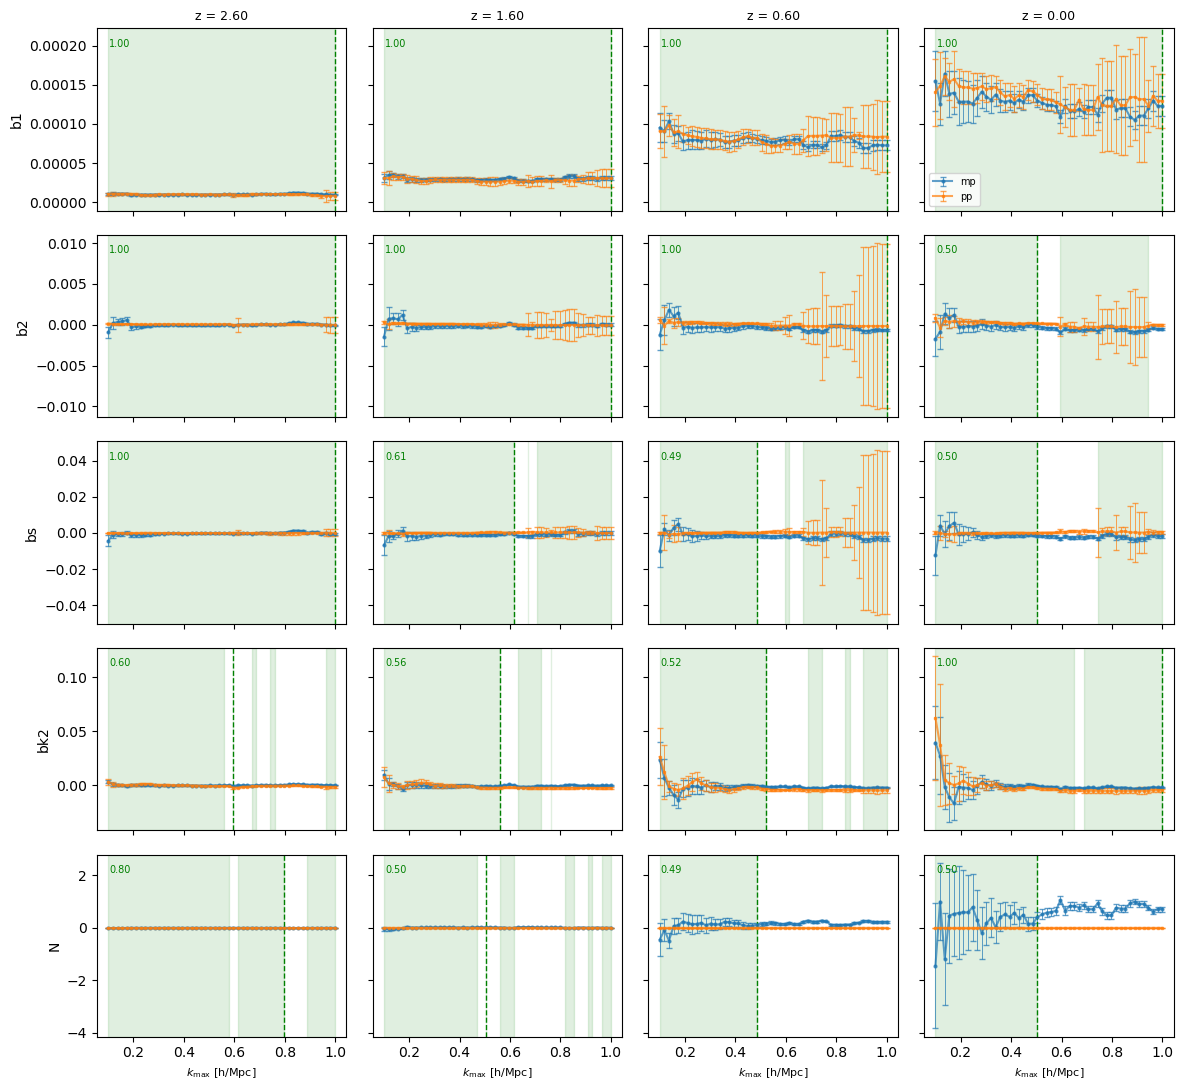

In [141]:
fig, breakdowns = grid_bias_plots(snaps, kmaxes)

### fgas+2sigma

In [11]:
# Set a base snapshot
snpk = SnapPk('fgas+2sigma', 67, kmax=10)

#### Fitting Matter-Pressure

Fit results: b1=8.076e-06, b2=-8.126e-04, bs=-3.720e-03, bk2=0.00259, N=-5.257e-03, chi2/ndof=0.11
Fit results: b1=8.076e-06, b2=-8.126e-04, bs=-3.720e-03, bk2=2.586e-03, N=-5.257e-03, chi2/ndof=0.11


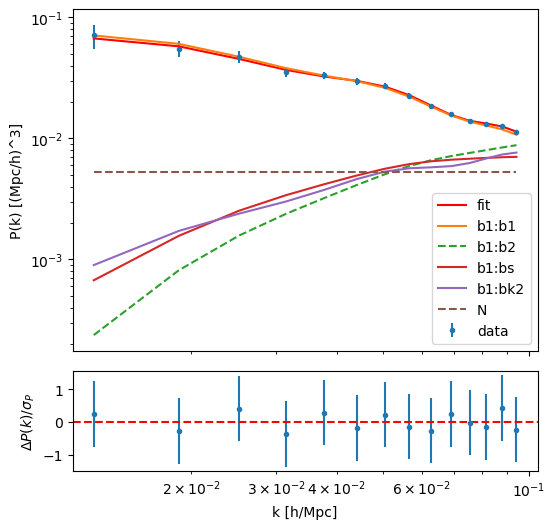

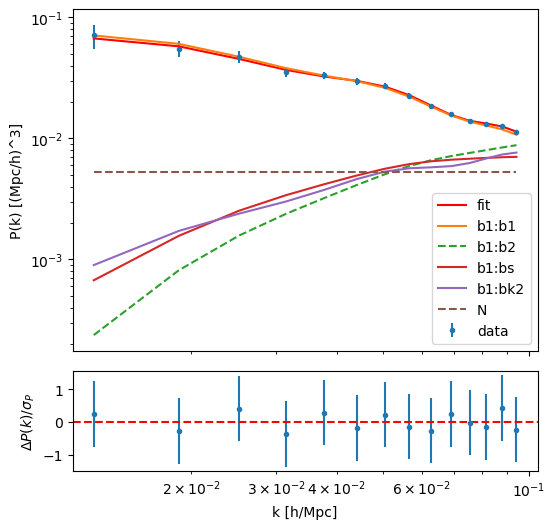

In [12]:
b_bf_ana, b_cov_ana = fit_pk_analytic(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]
b_bf, b_cov = fit_pk(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]

#### Fitting Pressure-Pressure

Fit results: b1=8.030e-06, b2=1.324e-04, bs=-1.246e-06, bk2=2.687e-03, N=-3.260e-07, chi2/ndof=0.31
[ 8.03000751e-06  1.32426840e-04 -1.24618840e-06  2.68661669e-03
 -3.25963231e-07]


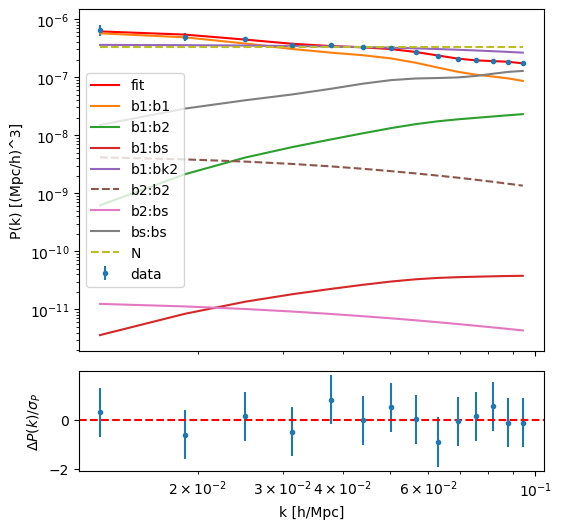

In [13]:
b_bf, b_cov = fit_pk(snpk, snpk.pks['pressure_pressure'], snpk.epks['pressure_pressure'], kmax=0.1, kmin=0.01, nl = True)[:2]

#### Comparing Fits

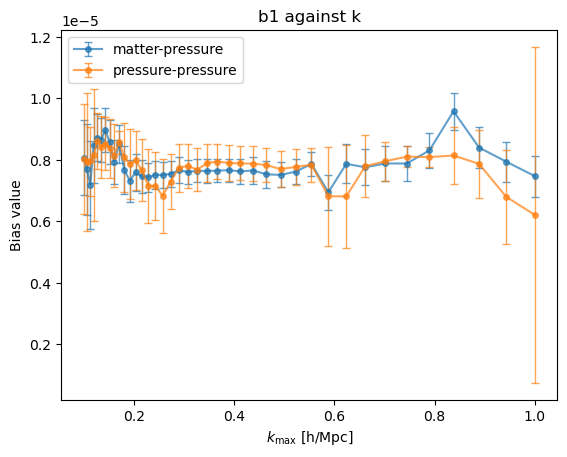

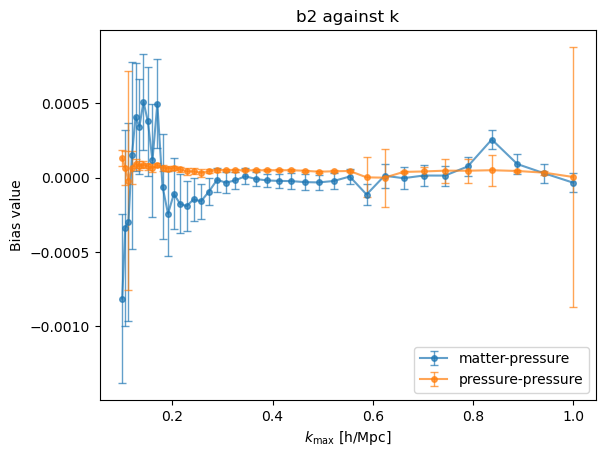

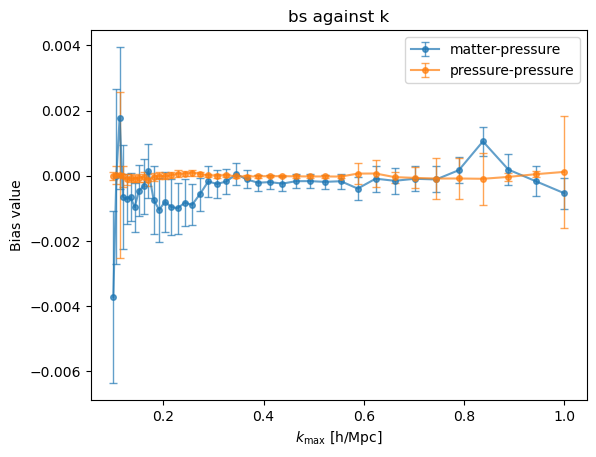

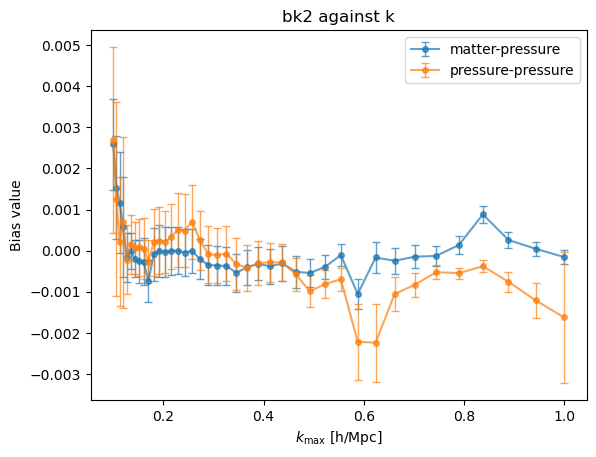

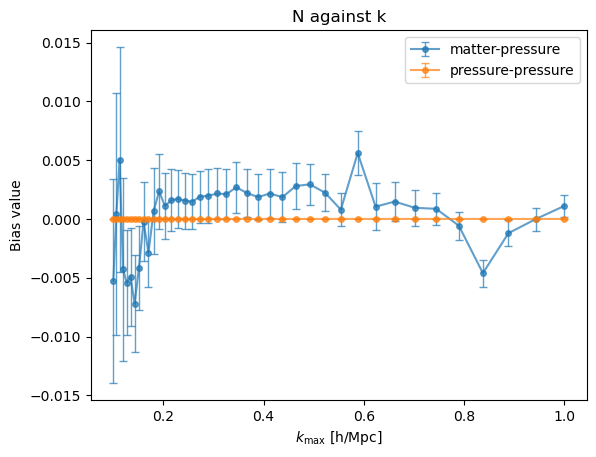

In [14]:
# Set kmaxes
kmaxes = np.geomspace(0.1, 1, 40)
coefficient_plotter(snpk, kmaxes, which = None)

### fgas-2sigma

In [15]:
# Set a base snapshot
snpk = SnapPk('fgas-2sigma', 67, kmax=10)

#### Fitting Matter-Pressure

Fit results: b1=9.078e-06, b2=-7.829e-04, bs=-3.709e-03, bk2=0.00261, N=-5.629e-03, chi2/ndof=0.10
Fit results: b1=9.078e-06, b2=-7.829e-04, bs=-3.709e-03, bk2=2.610e-03, N=-5.629e-03, chi2/ndof=0.10


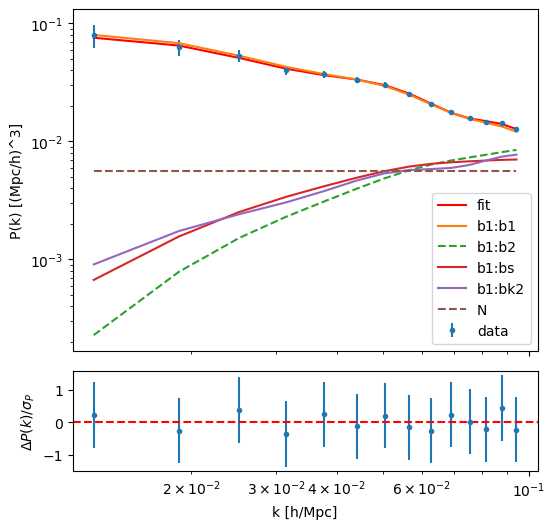

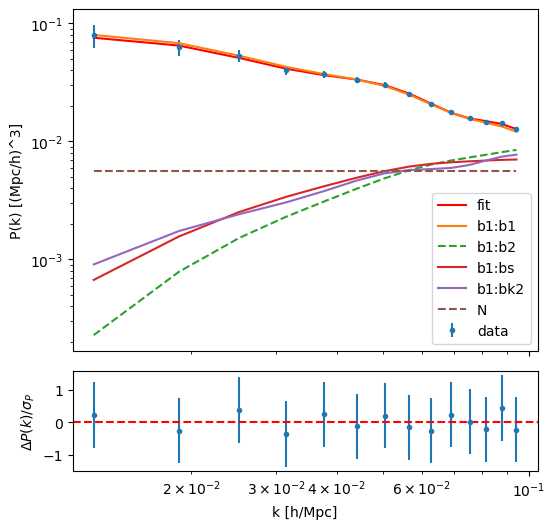

In [16]:
b_bf_ana, b_cov_ana = fit_pk_analytic(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]
b_bf, b_cov = fit_pk(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]

#### Fitting Pressure-Pressure

Fit results: b1=9.145e-06, b2=1.422e-04, bs=-1.227e-05, bk2=2.517e-03, N=-3.630e-07, chi2/ndof=0.24
[ 9.14509602e-06  1.42246616e-04 -1.22685232e-05  2.51747022e-03
 -3.62962875e-07]


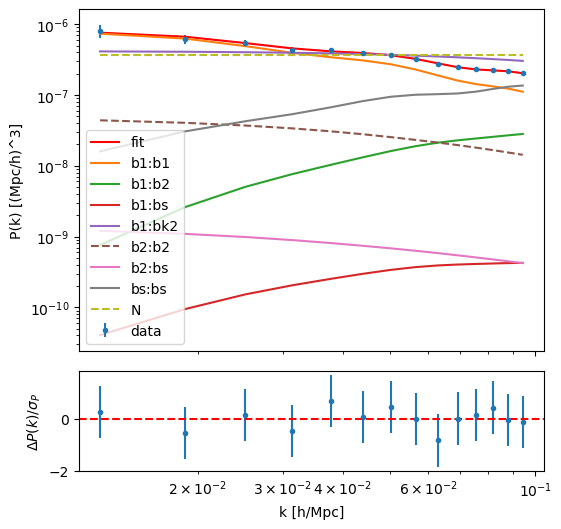

In [17]:
b_bf, b_cov = fit_pk(snpk, snpk.pks['pressure_pressure'], snpk.epks['pressure_pressure'], kmax=0.1, kmin=0.01, nl = True)[:2]

#### Comparing Fits

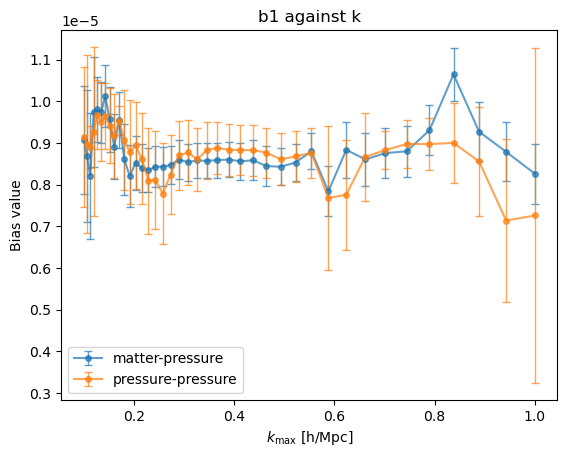

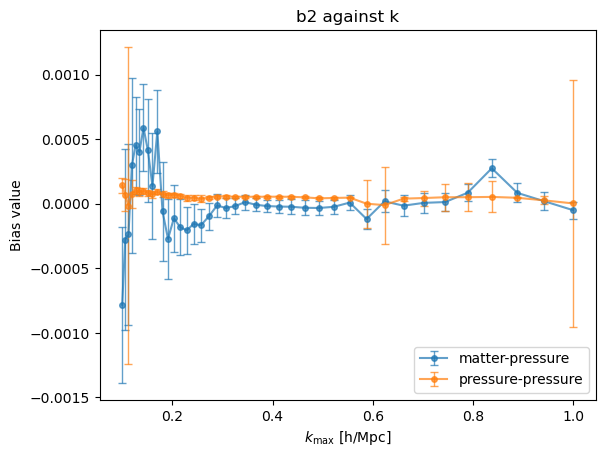

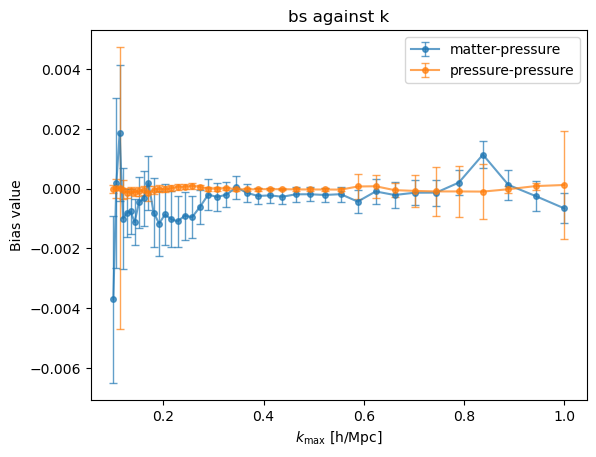

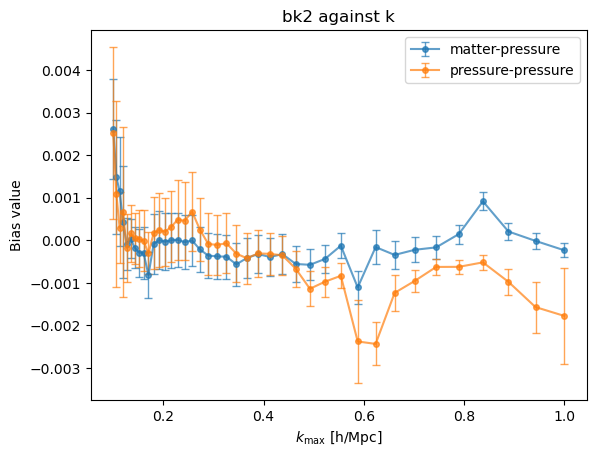

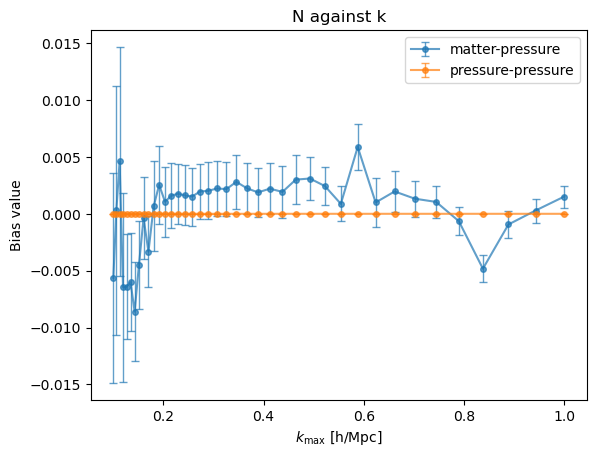

In [18]:
# Set kmaxes
kmaxes = np.geomspace(0.1, 1, 40)
coefficient_plotter(snpk, kmaxes, which = None)

### fgas-4sigma

In [19]:
# Set a base snapshot
snpk = SnapPk('fgas-4sigma', 67, kmax=10)

#### Fitting Matter-Pressure

Fit results: b1=9.506e-06, b2=-8.557e-04, bs=-3.538e-03, bk2=0.00279, N=-4.843e-03, chi2/ndof=0.10
Fit results: b1=9.506e-06, b2=-8.557e-04, bs=-3.538e-03, bk2=2.794e-03, N=-4.843e-03, chi2/ndof=0.10


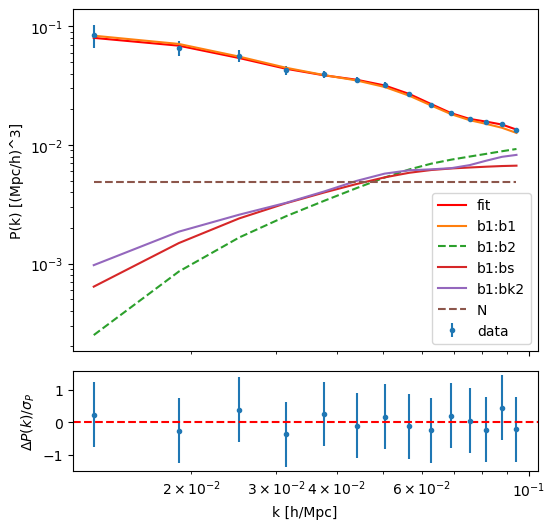

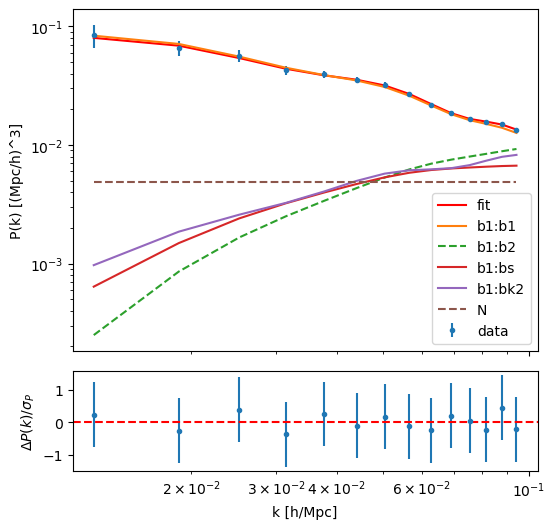

In [20]:
b_bf_ana, b_cov_ana = fit_pk_analytic(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]
b_bf, b_cov = fit_pk(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]

#### Fitting Pressure-Pressure

Fit results: b1=9.685e-06, b2=1.471e-04, bs=-9.904e-06, bk2=2.652e-03, N=-3.987e-07, chi2/ndof=0.24
[ 9.68456117e-06  1.47076123e-04 -9.90385145e-06  2.65176270e-03
 -3.98726592e-07]


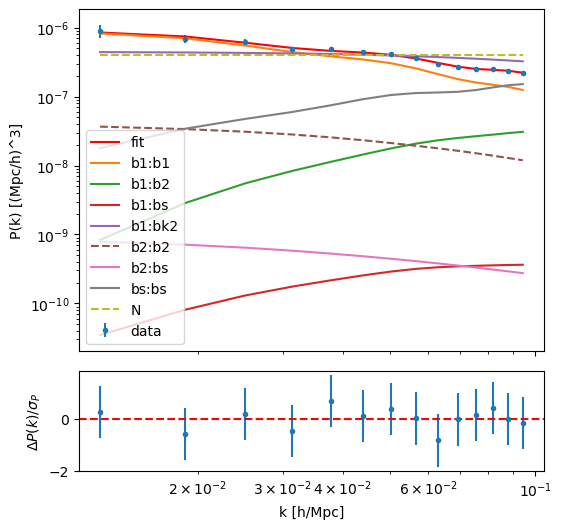

In [21]:
b_bf, b_cov = fit_pk(snpk, snpk.pks['pressure_pressure'], snpk.epks['pressure_pressure'], kmax=0.1, kmin=0.01, nl = True)[:2]

#### Comparing Fits

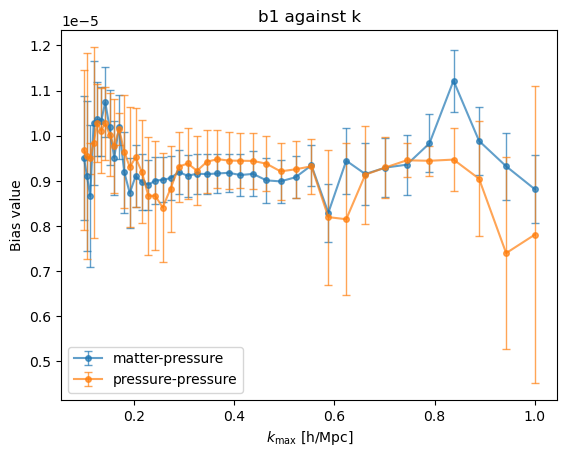

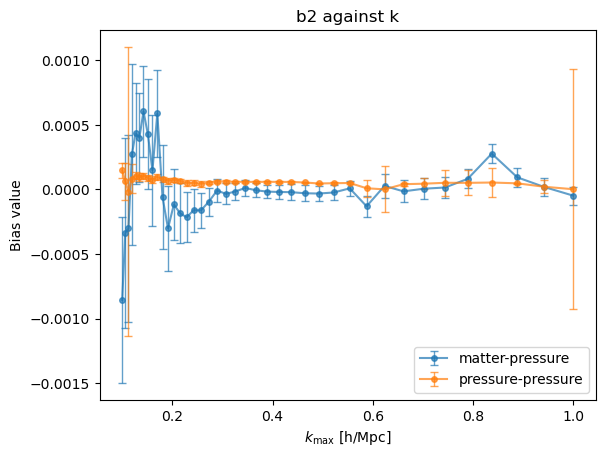

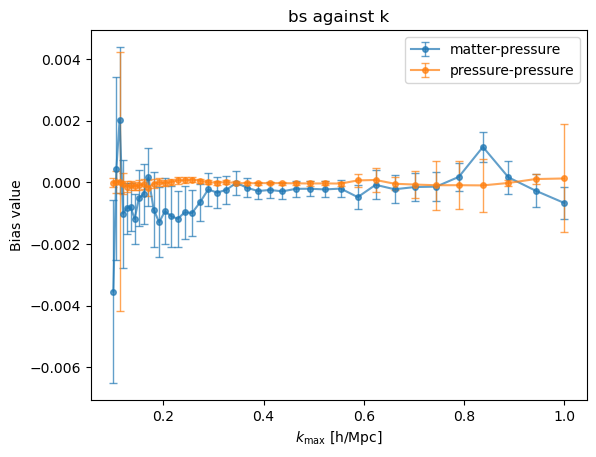

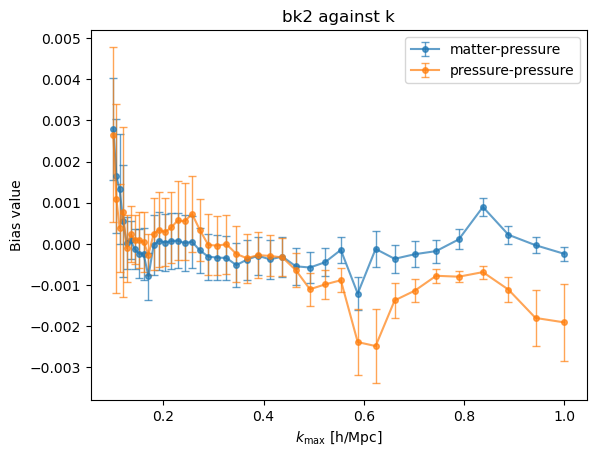

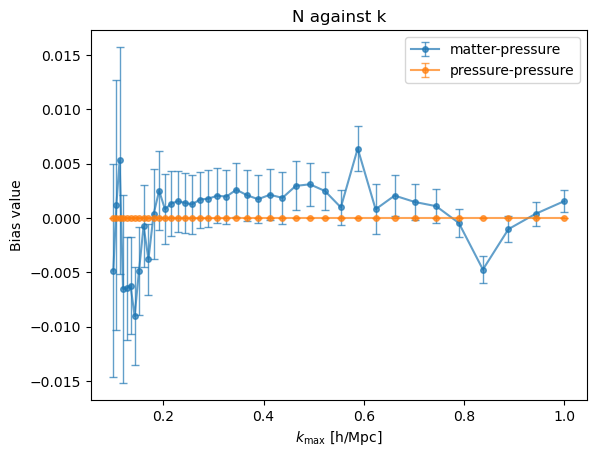

In [22]:
# Set kmaxes
kmaxes = np.geomspace(0.1, 1, 40)
coefficient_plotter(snpk, kmaxes, which = None)

### fgas-8sigma

In [23]:
# Set a base snapshot
snpk = SnapPk('fgas-8sigma', 67, kmax=10)

#### Fitting Matter-Pressure

Fit results: b1=1.090e-05, b2=-8.675e-04, bs=-3.952e-03, bk2=0.00294, N=-5.993e-03, chi2/ndof=0.09
Fit results: b1=1.090e-05, b2=-8.675e-04, bs=-3.952e-03, bk2=2.939e-03, N=-5.993e-03, chi2/ndof=0.09


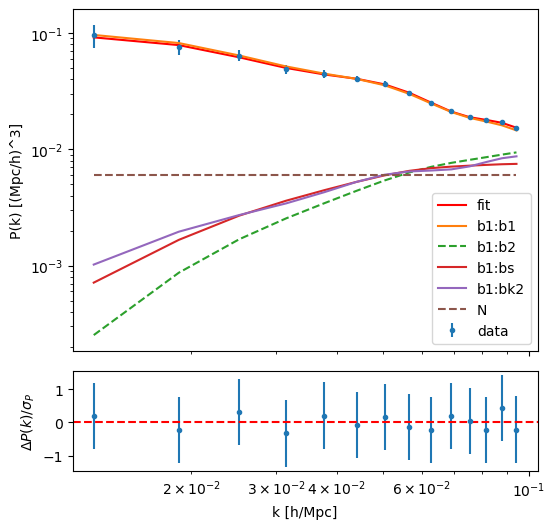

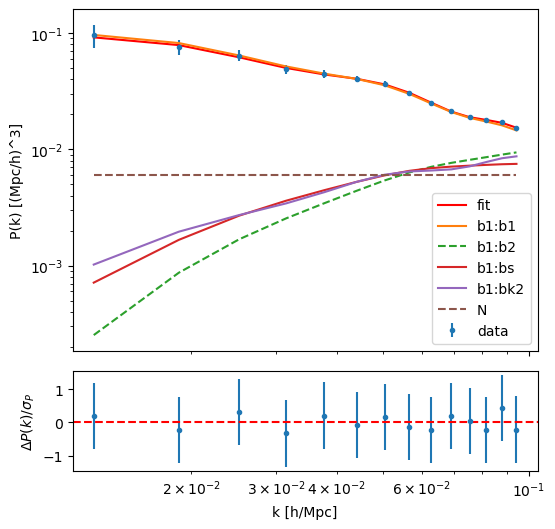

In [24]:
b_bf_ana, b_cov_ana = fit_pk_analytic(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]
b_bf, b_cov = fit_pk(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]

#### Fitting Pressure-Pressure

Fit results: b1=1.134e-05, b2=1.737e-04, bs=-3.874e-05, bk2=2.572e-03, N=-5.176e-07, chi2/ndof=0.19
[ 1.13405837e-05  1.73694683e-04 -3.87390203e-05  2.57227003e-03
 -5.17613222e-07]


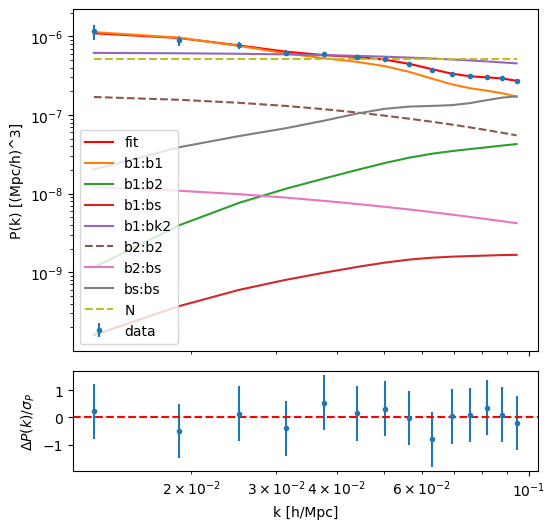

In [25]:
b_bf, b_cov = fit_pk(snpk, snpk.pks['pressure_pressure'], snpk.epks['pressure_pressure'], kmax=0.1, kmin=0.01, nl = True)[:2]

#### Comparing Fits

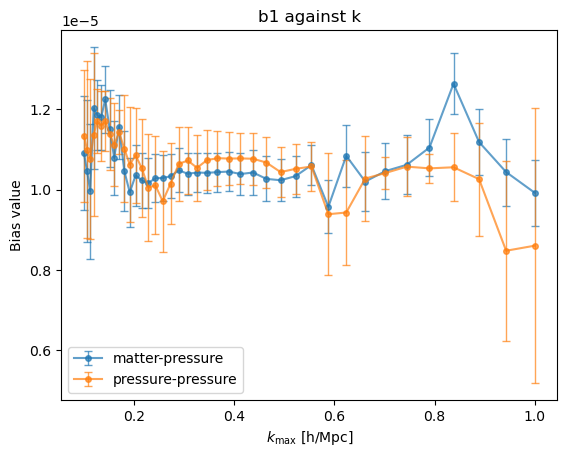

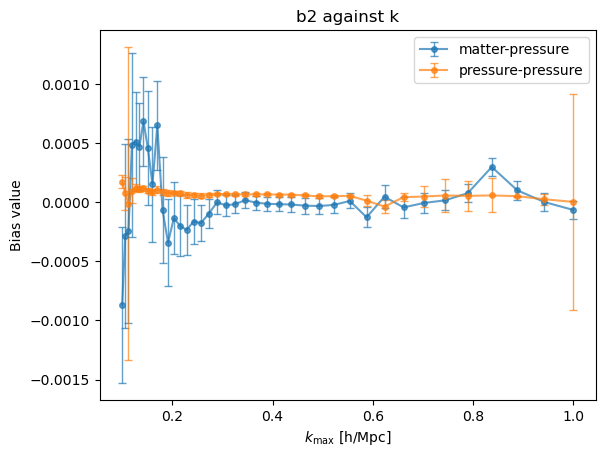

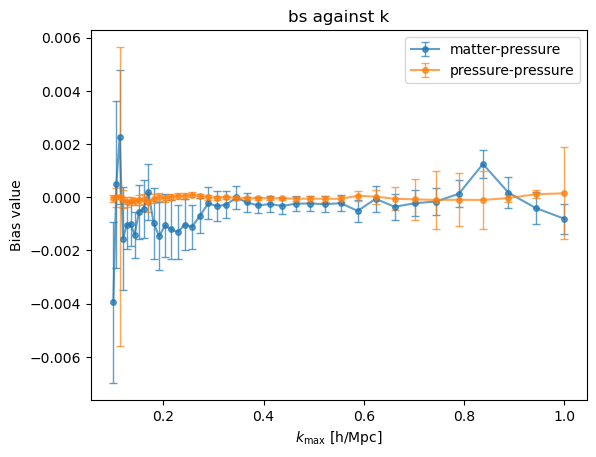

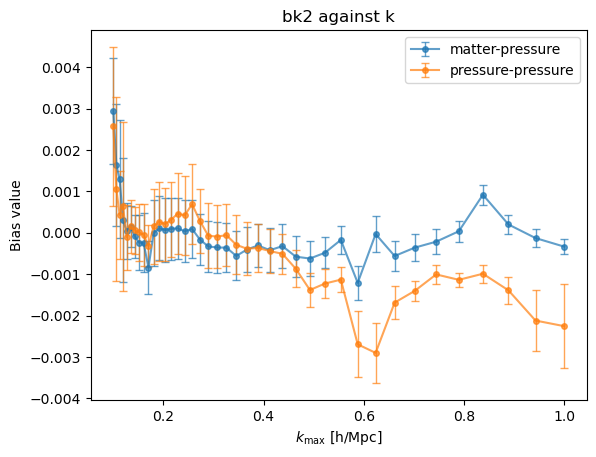

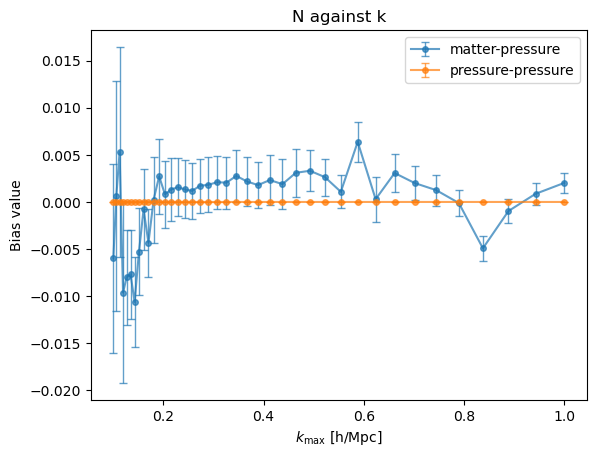

In [26]:
# Set kmaxes
kmaxes = np.geomspace(0.1, 1, 40)
coefficient_plotter(snpk, kmaxes, which = None)

### Jet

In [27]:
# Set a base snapshot
snpk = SnapPk('Jet', 67, kmax=10)

#### Fitting Matter-Pressure

Fit results: b1=7.667e-06, b2=-8.028e-04, bs=-3.701e-03, bk2=0.00252, N=-5.209e-03, chi2/ndof=0.11
Fit results: b1=7.667e-06, b2=-8.028e-04, bs=-3.701e-03, bk2=2.522e-03, N=-5.209e-03, chi2/ndof=0.11


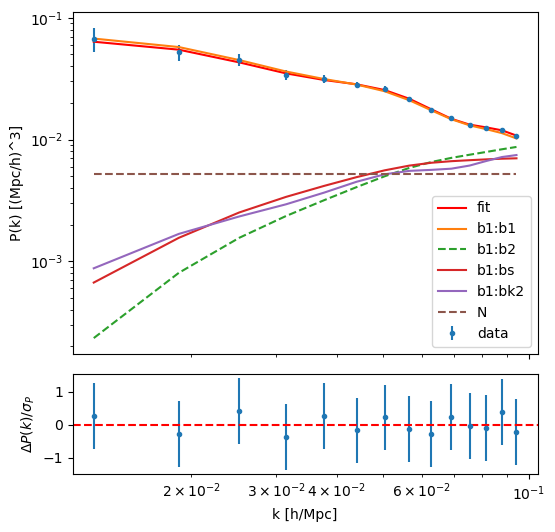

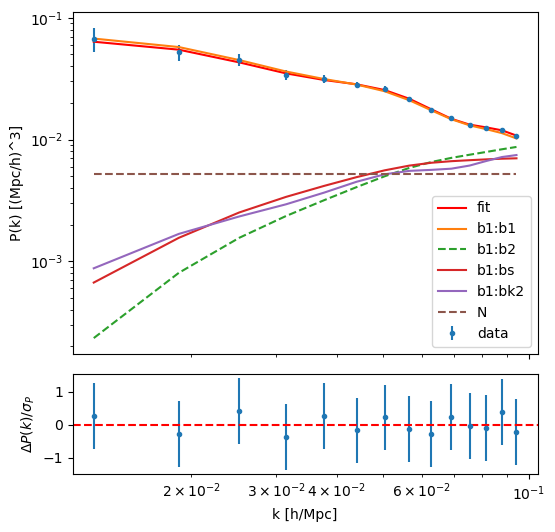

In [28]:
b_bf_ana, b_cov_ana = fit_pk_analytic(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]
b_bf, b_cov = fit_pk(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]

#### Fitting Pressure-Pressure

Fit results: b1=7.595e-06, b2=1.277e-04, bs=2.511e-06, bk2=2.699e-03, N=-3.086e-07, chi2/ndof=0.33
[ 7.59500951e-06  1.27728068e-04  2.51104402e-06  2.69870566e-03
 -3.08565849e-07]


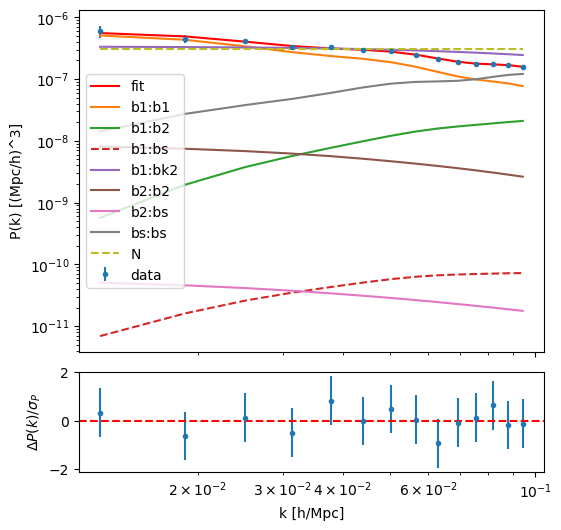

In [29]:
b_bf, b_cov = fit_pk(snpk, snpk.pks['pressure_pressure'], snpk.epks['pressure_pressure'], kmax=0.1, kmin=0.01, nl = True)[:2]

#### Comparing Fits

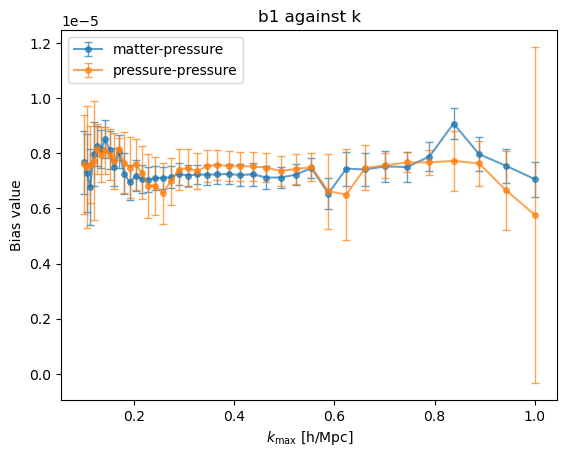

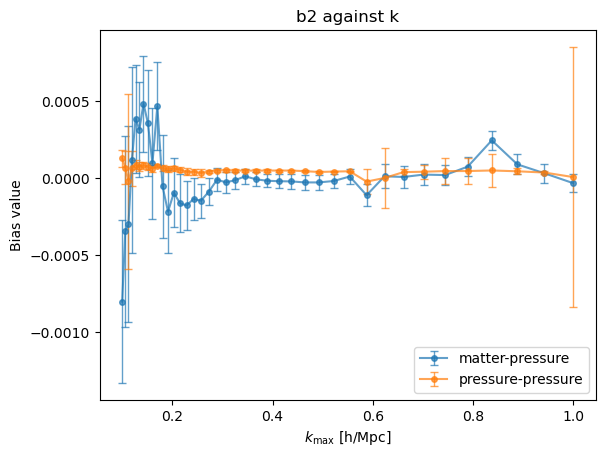

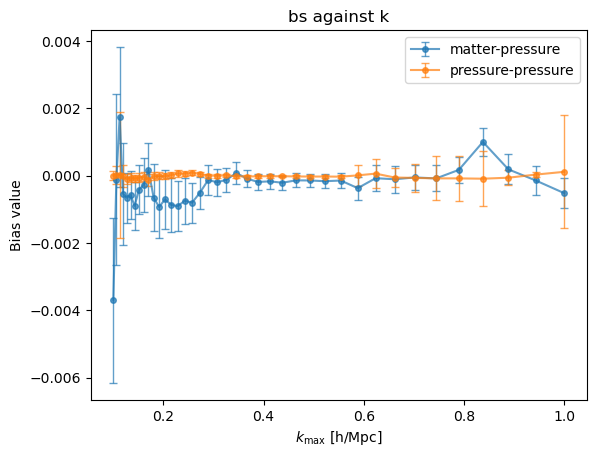

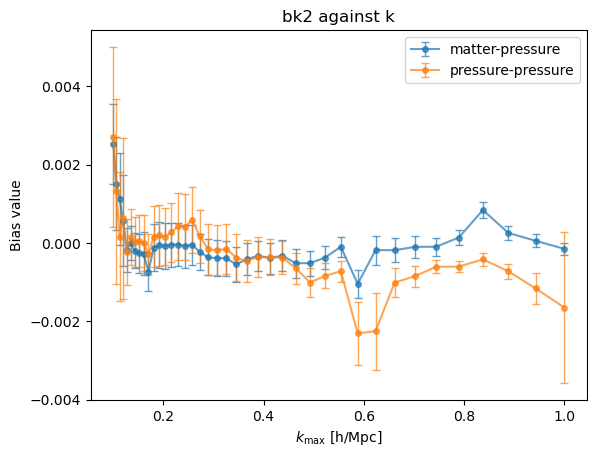

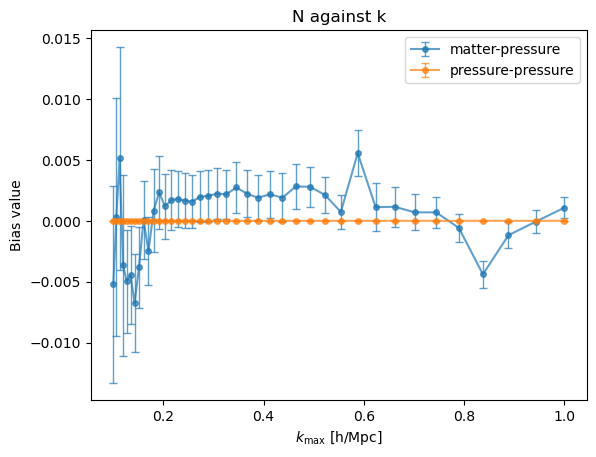

In [30]:
# Set kmaxes
kmaxes = np.geomspace(0.1, 1, 40)
coefficient_plotter(snpk, kmaxes, which = None)

### Jet_fgas-4sigma

In [31]:
# Set a base snapshot
snpk = SnapPk('Jet_fgas-4sigma', 67, kmax=10)

#### Fitting Matter-Pressure

Fit results: b1=1.150e-05, b2=-1.157e-03, bs=-4.218e-03, bk2=0.00352, N=-4.678e-03, chi2/ndof=0.10
Fit results: b1=1.150e-05, b2=-1.157e-03, bs=-4.218e-03, bk2=3.519e-03, N=-4.678e-03, chi2/ndof=0.10


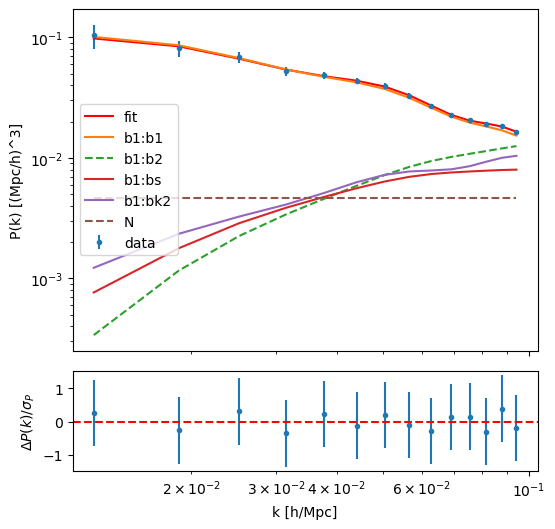

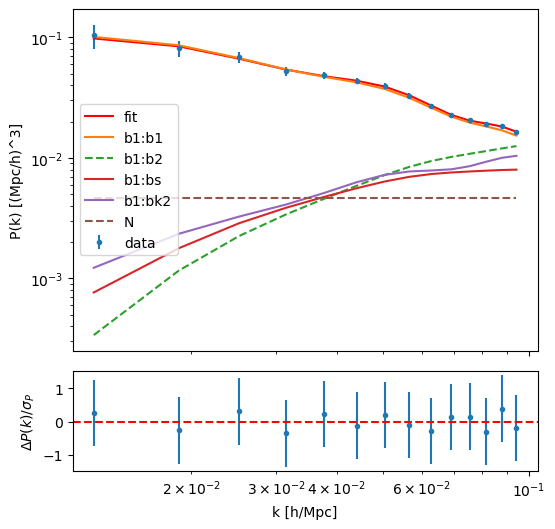

In [32]:
b_bf_ana, b_cov_ana = fit_pk_analytic(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]
b_bf, b_cov = fit_pk(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]

#### Fitting Pressure-Pressure

Fit results: b1=1.186e-05, b2=1.853e-04, bs=-9.845e-06, bk2=3.339e-03, N=-6.585e-07, chi2/ndof=0.23
[ 1.18589469e-05  1.85261112e-04 -9.84471850e-06  3.33911723e-03
 -6.58470069e-07]


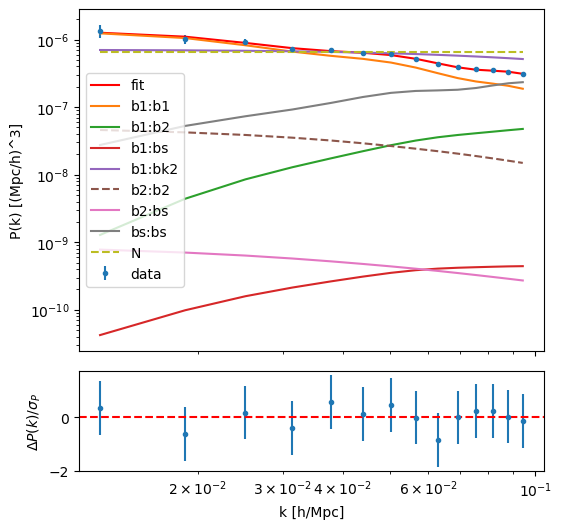

In [33]:
b_bf, b_cov = fit_pk(snpk, snpk.pks['pressure_pressure'], snpk.epks['pressure_pressure'], kmax=0.1, kmin=0.01, nl = True)[:2]

#### Comparing Fits

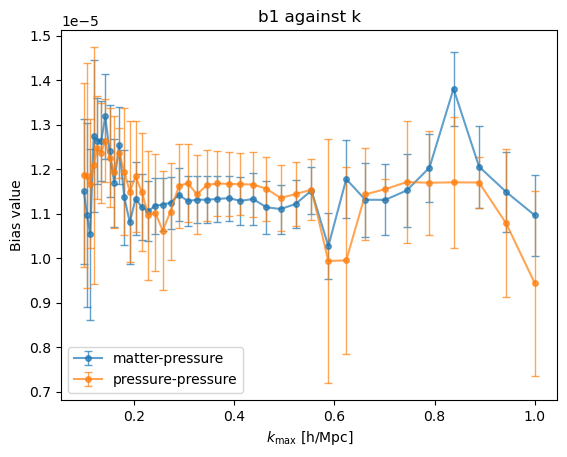

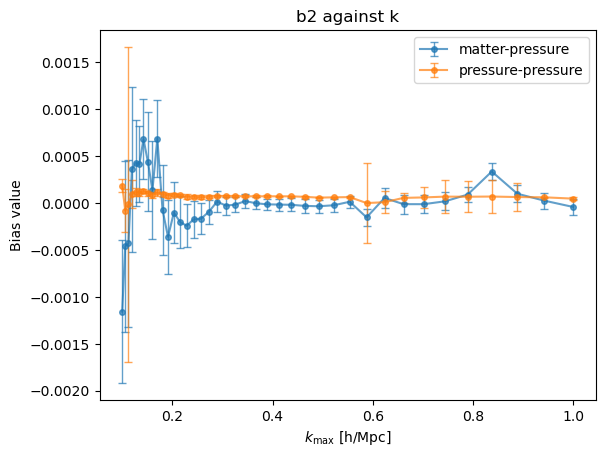

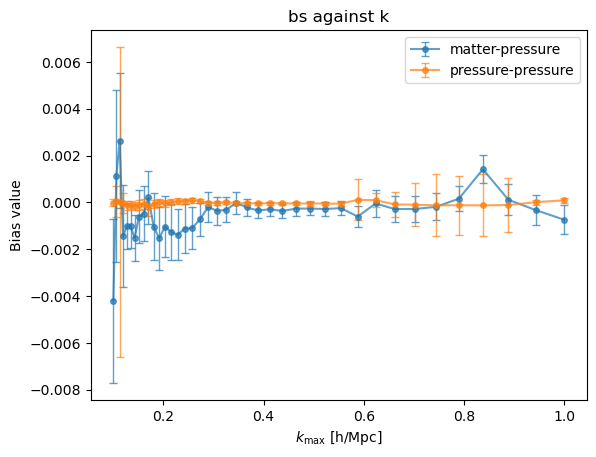

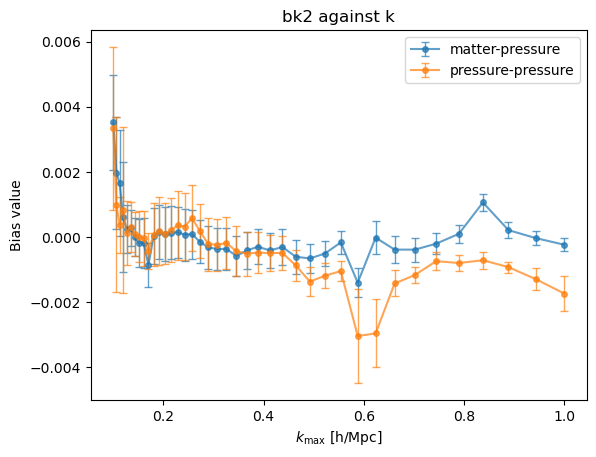

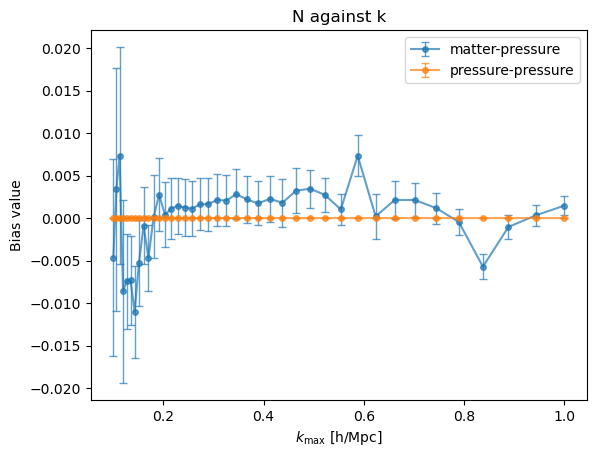

In [34]:
# Set kmaxes
kmaxes = np.geomspace(0.1, 1, 40)
coefficient_plotter(snpk, kmaxes, which = None)

### Mstar-1sigma

In [35]:
# Set a base snapshot
snpk = SnapPk('Mstar-1sigma', 67, kmax=10)

#### Fitting Matter-Pressure

Fit results: b1=9.265e-06, b2=-9.016e-04, bs=-3.650e-03, bk2=0.00289, N=-4.813e-03, chi2/ndof=0.11
Fit results: b1=9.265e-06, b2=-9.016e-04, bs=-3.650e-03, bk2=2.889e-03, N=-4.813e-03, chi2/ndof=0.11


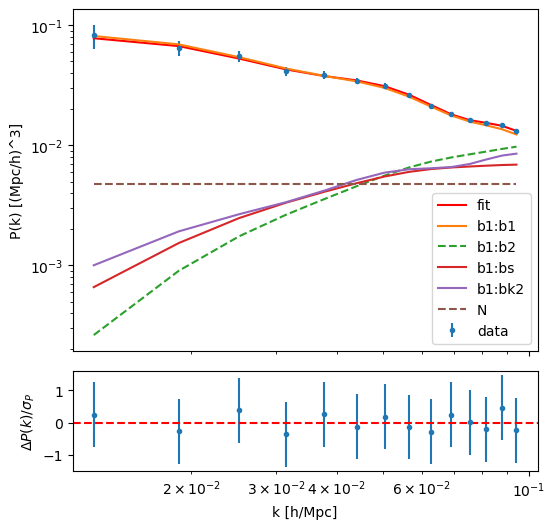

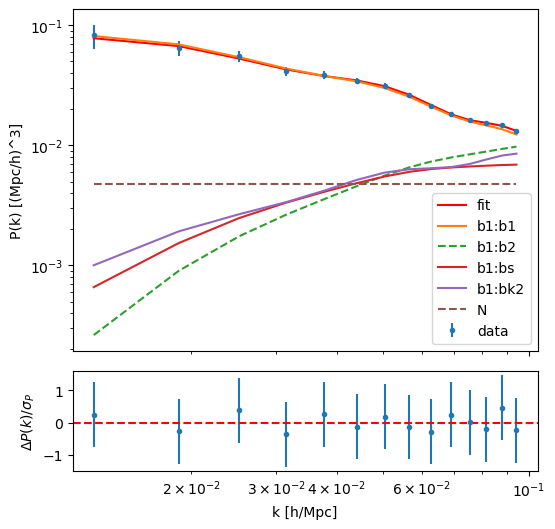

In [36]:
b_bf_ana, b_cov_ana = fit_pk_analytic(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]
b_bf, b_cov = fit_pk(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]

#### Fitting Pressure-Pressure

Fit results: b1=9.367e-06, b2=1.461e-04, bs=-1.777e-06, bk2=2.901e-03, N=-4.098e-07, chi2/ndof=0.26
[ 9.36725768e-06  1.46097552e-04 -1.77666073e-06  2.90105526e-03
 -4.09844021e-07]


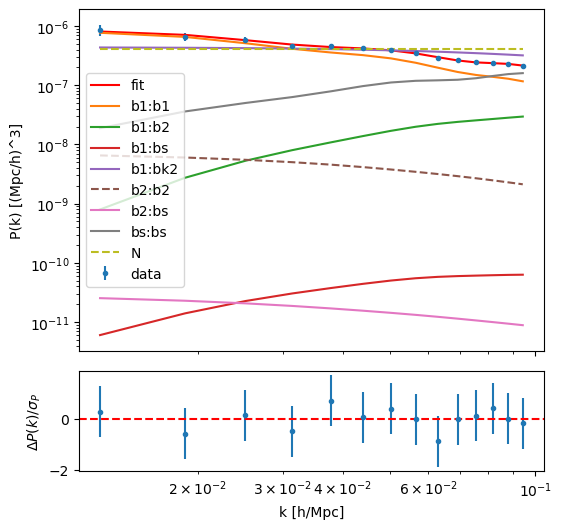

In [37]:
b_bf, b_cov = fit_pk(snpk, snpk.pks['pressure_pressure'], snpk.epks['pressure_pressure'], kmax=0.1, kmin=0.01, nl = True)[:2]

#### Comparing Fits

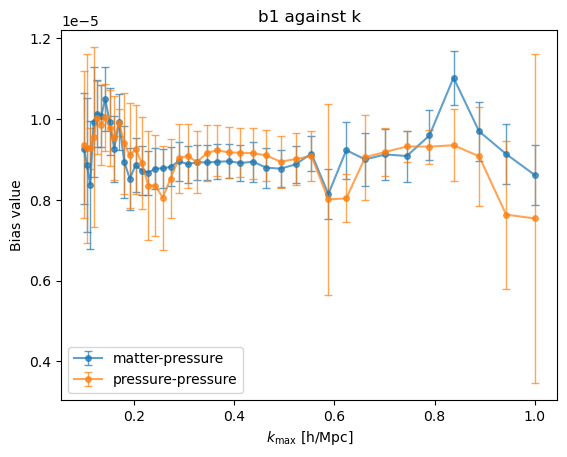

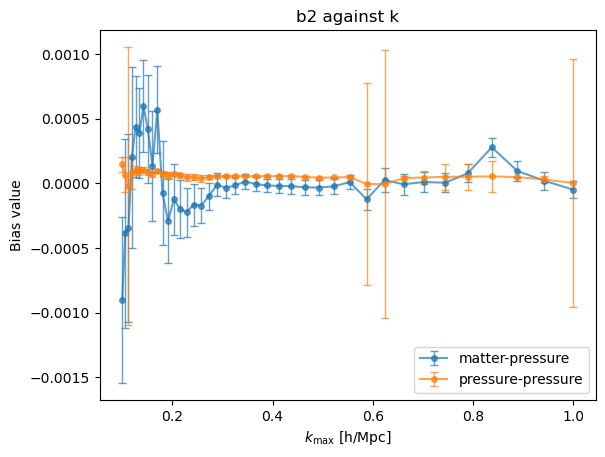

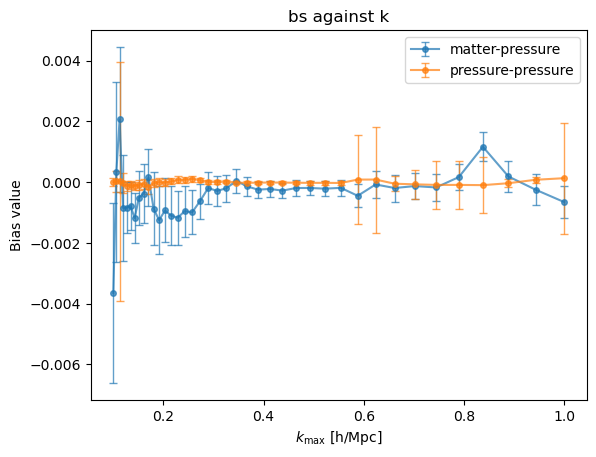

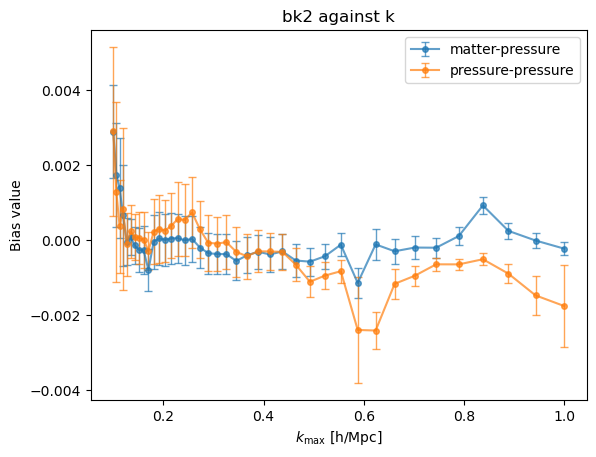

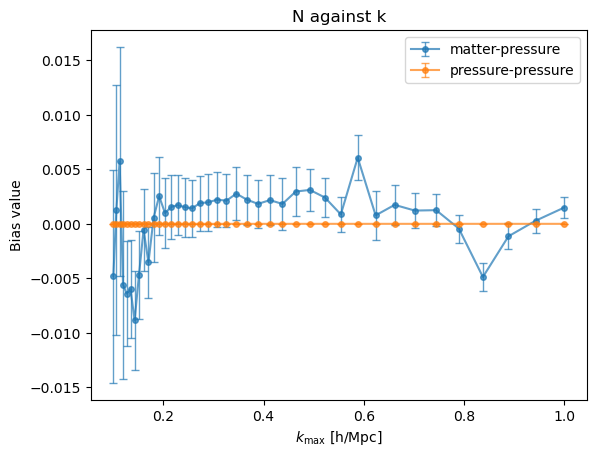

In [38]:
# Set kmaxes
kmaxes = np.geomspace(0.1, 1, 40)
coefficient_plotter(snpk, kmaxes, which = None)

### Mstar-1sigma_fgas-4sigma

In [39]:
# Set a base snapshot
snpk = SnapPk('Mstar-1sigma_fgas-4sigma', 67, kmax=10)

#### Fitting Matter-Pressure

Fit results: b1=1.049e-05, b2=-9.935e-04, bs=-3.857e-03, bk2=0.00318, N=-4.932e-03, chi2/ndof=0.11
Fit results: b1=1.049e-05, b2=-9.935e-04, bs=-3.857e-03, bk2=3.180e-03, N=-4.932e-03, chi2/ndof=0.11


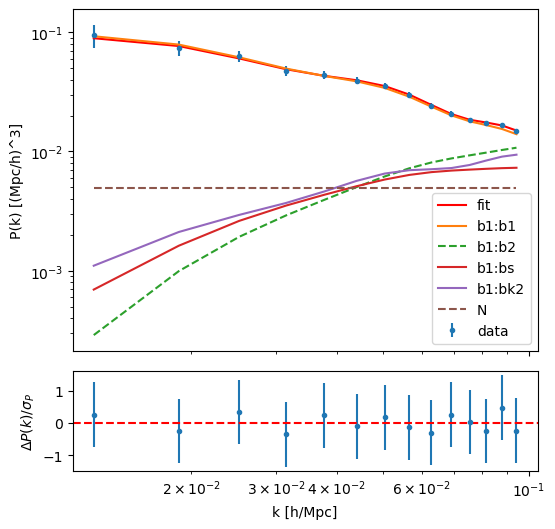

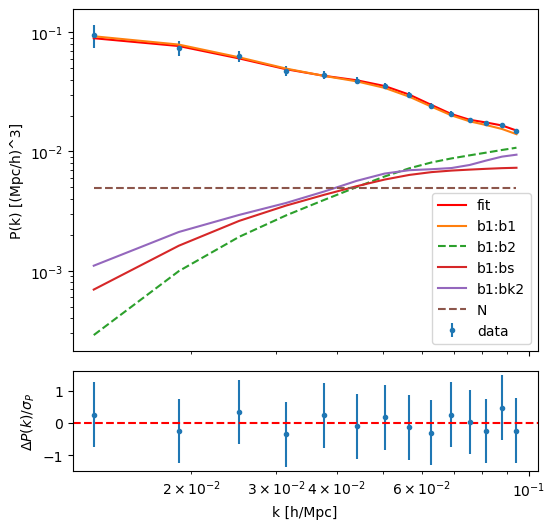

In [40]:
b_bf_ana, b_cov_ana = fit_pk_analytic(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]
b_bf, b_cov = fit_pk(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]

#### Fitting Pressure-Pressure

Fit results: b1=1.079e-05, b2=1.660e-04, bs=-1.389e-05, bk2=2.979e-03, N=-5.178e-07, chi2/ndof=0.24
[ 1.07915581e-05  1.66010354e-04 -1.38925448e-05  2.97892270e-03
 -5.17841813e-07]


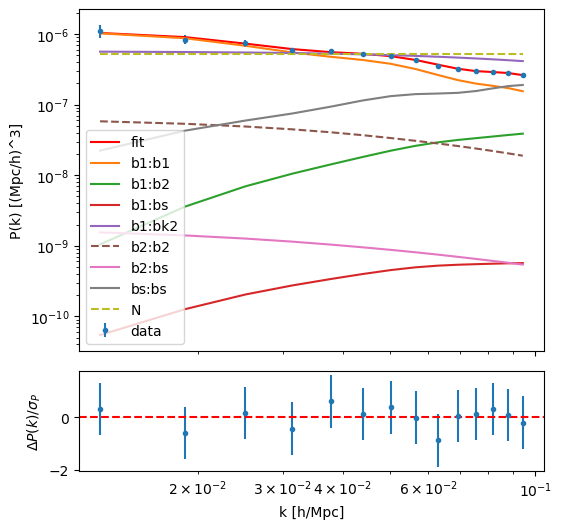

In [41]:
b_bf, b_cov = fit_pk(snpk, snpk.pks['pressure_pressure'], snpk.epks['pressure_pressure'], kmax=0.1, kmin=0.01, nl = True)[:2]

#### Comparing Fits

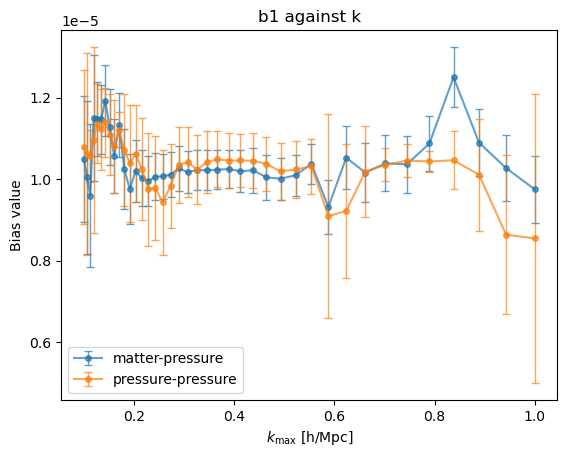

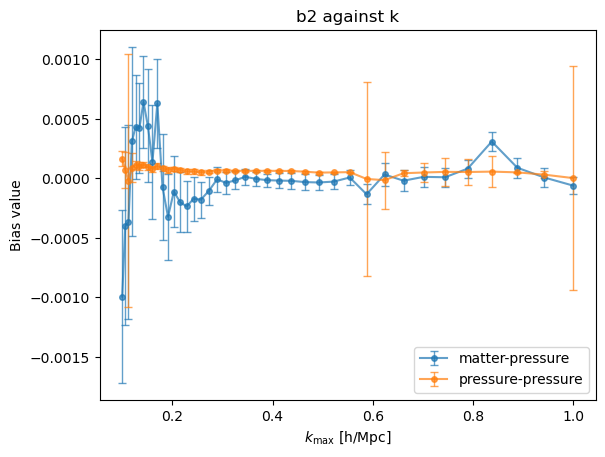

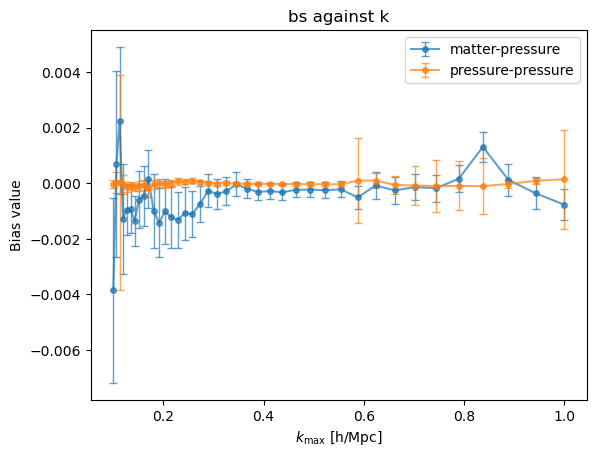

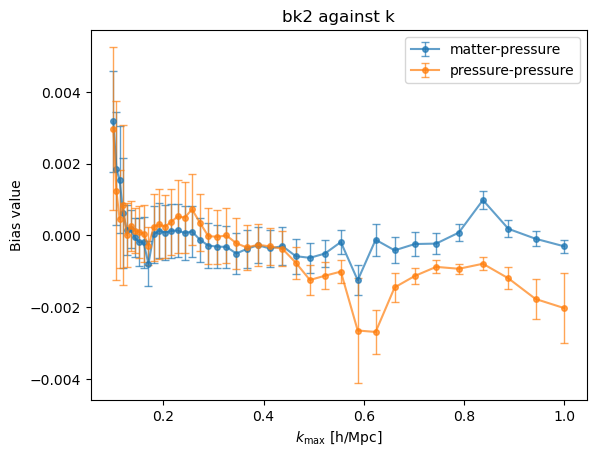

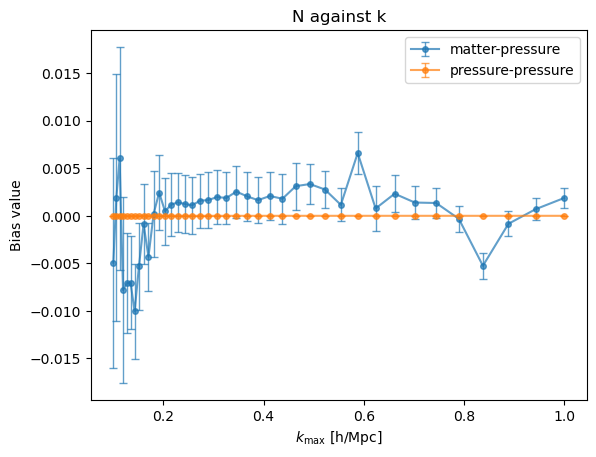

In [42]:
# Set kmaxes
kmaxes = np.geomspace(0.1, 1, 40)
coefficient_plotter(snpk, kmaxes, which = None)

### NoCooling

In [43]:
# Set a base snapshot
snpk = SnapPk('NoCooling', 67, kmax=10)

#### Fitting Matter-Pressure

Fit results: b1=1.358e-05, b2=-1.308e-03, bs=-4.516e-03, bk2=0.00399, N=-4.760e-03, chi2/ndof=0.10
Fit results: b1=1.358e-05, b2=-1.308e-03, bs=-4.516e-03, bk2=3.989e-03, N=-4.760e-03, chi2/ndof=0.10


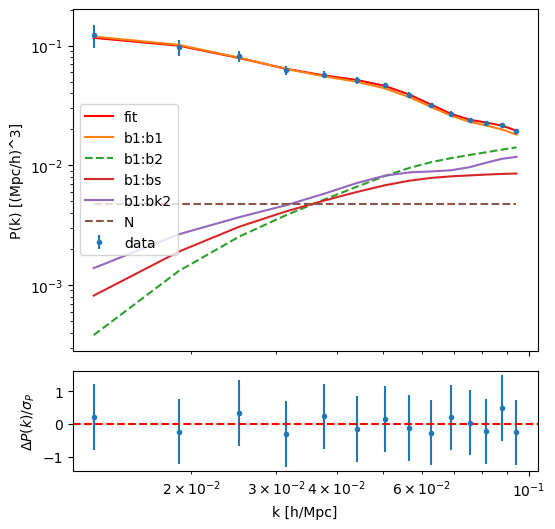

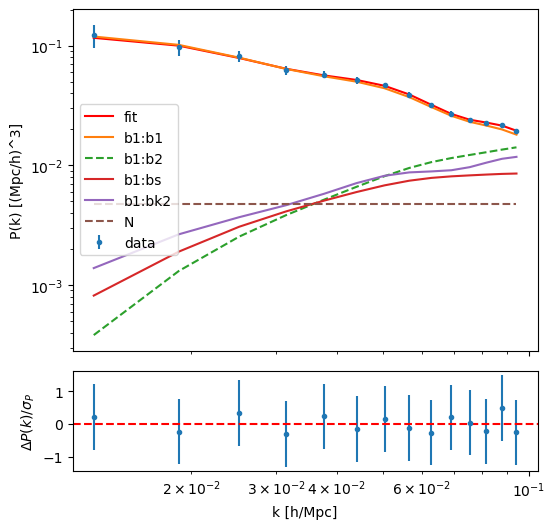

In [44]:
b_bf_ana, b_cov_ana = fit_pk_analytic(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]
b_bf, b_cov = fit_pk(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]

#### Fitting Pressure-Pressure

Fit results: b1=1.398e-05, b2=2.037e-04, bs=1.463e-06, bk2=4.009e-03, N=-8.585e-07, chi2/ndof=0.20
[ 1.39751710e-05  2.03745068e-04  1.46295377e-06  4.00906618e-03
 -8.58540343e-07]


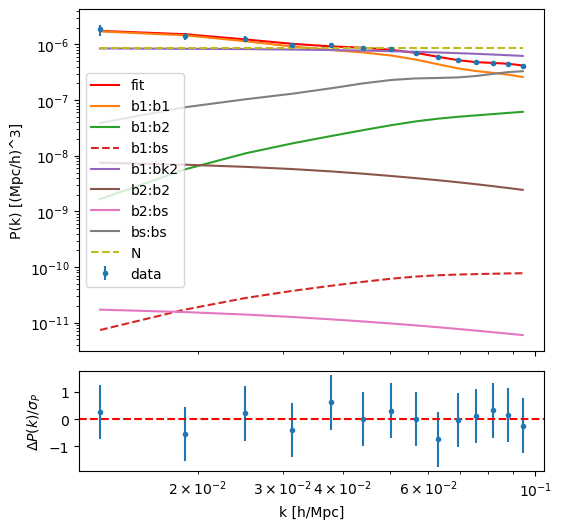

In [45]:
b_bf, b_cov = fit_pk(snpk, snpk.pks['pressure_pressure'], snpk.epks['pressure_pressure'], kmax=0.1, kmin=0.01, nl = True)[:2]

#### Comparing Fits

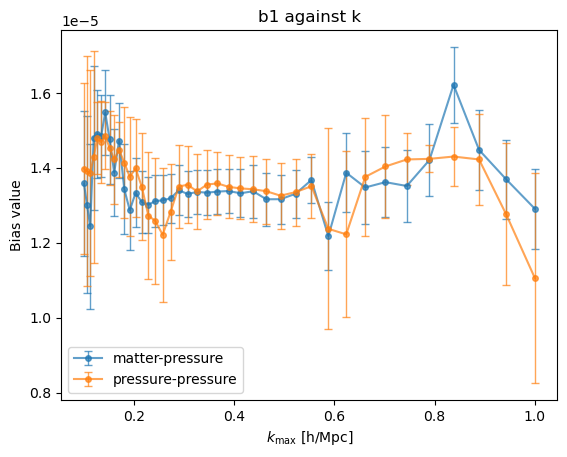

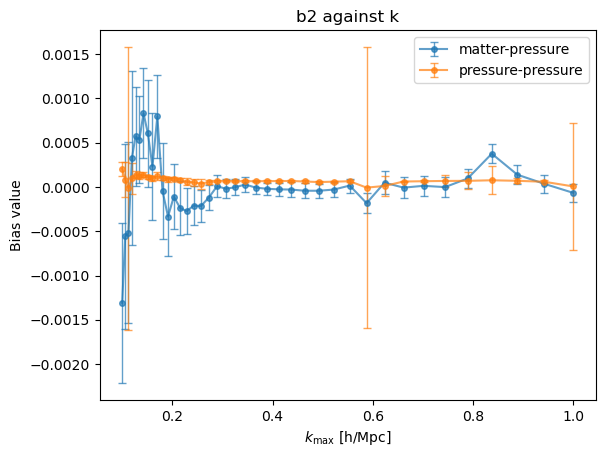

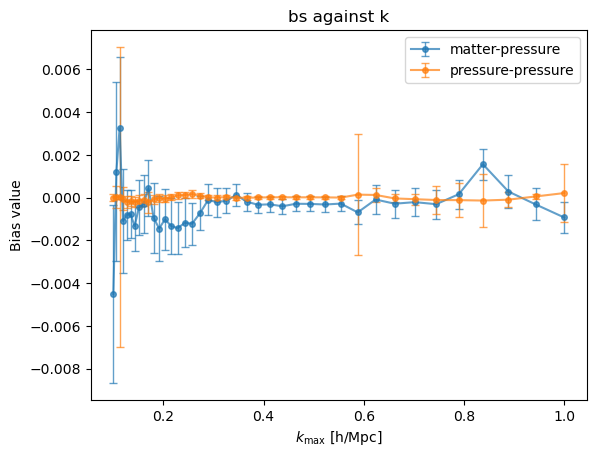

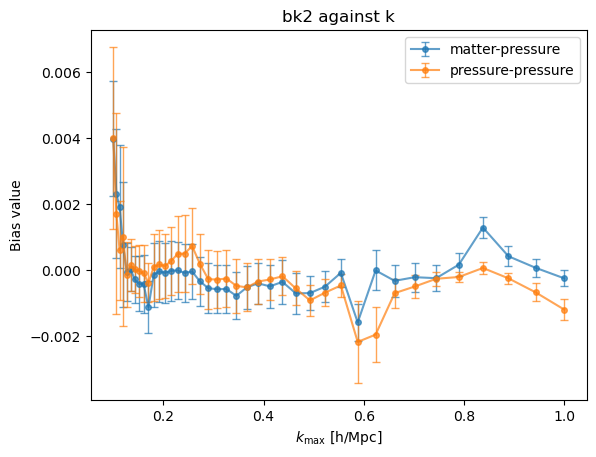

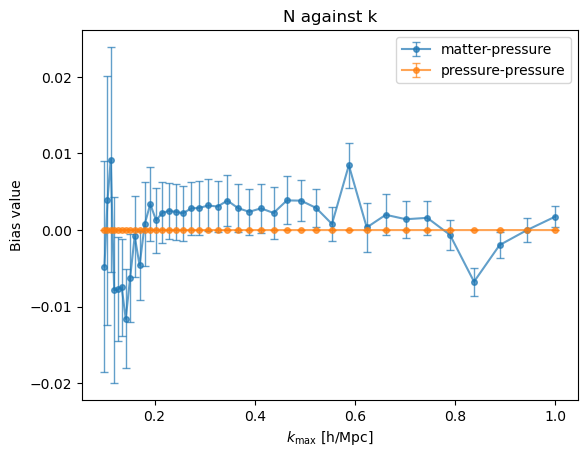

In [46]:
# Set kmaxes
kmaxes = np.geomspace(0.1, 1, 40)
coefficient_plotter(snpk, kmaxes, which = None)

## Cosmology Variations

### Planck

In [47]:
# Set a base snapshot
snpk = SnapPk('Planck', 67, kmax=10)
# And the right cosmological parameters
cosmo = ccl.Cosmology(h=0.673, Omega_b=0.0494, Omega_c=0.316-0.0494, n_s=0.966, sigma8=0.812)
ept = ccl.nl_pt.EulerianPTCalculator(with_NC=True, sub_lowk=False, b1_pk_kind='pt', bk2_pk_kind='linear')
ept.update_ingredients(cosmo)
pairs = ['b1:b1', 'b1:b2', 'b1:bs', 'b1:bk2', 'b2:b2', 'b2:bs', 'bs:bs']
pk2d_templates = {pair: ept.get_pk2d_template(pair) for pair in pairs}

#### Fitting Matter-Pressure

Fit results: b1=8.942e-06, b2=-8.603e-04, bs=-3.869e-03, bk2=0.0028, N=-5.735e-03, chi2/ndof=0.12
Fit results: b1=8.942e-06, b2=-8.603e-04, bs=-3.869e-03, bk2=2.804e-03, N=-5.735e-03, chi2/ndof=0.12


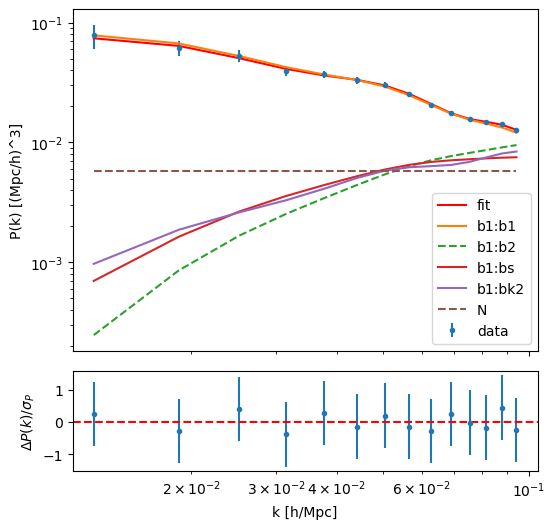

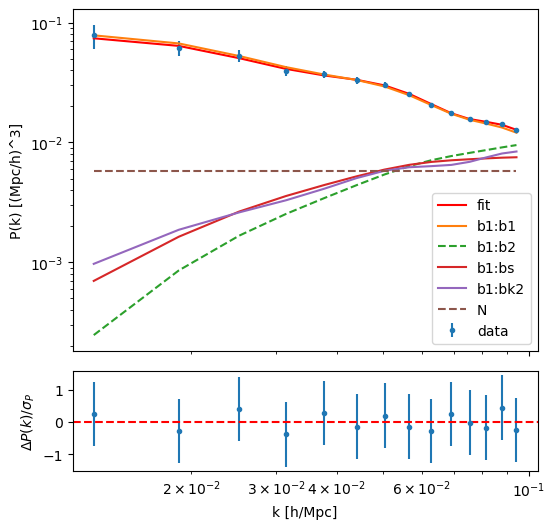

In [48]:
b_bf_ana, b_cov_ana = fit_pk_analytic(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]
b_bf, b_cov = fit_pk(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]

#### Fitting Pressure-Pressure

Fit results: b1=8.846e-06, b2=1.415e-04, bs=3.295e-06, bk2=2.958e-03, N=-3.967e-07, chi2/ndof=0.30
[ 8.84619506e-06  1.41494801e-04  3.29467552e-06  2.95756489e-03
 -3.96743596e-07]


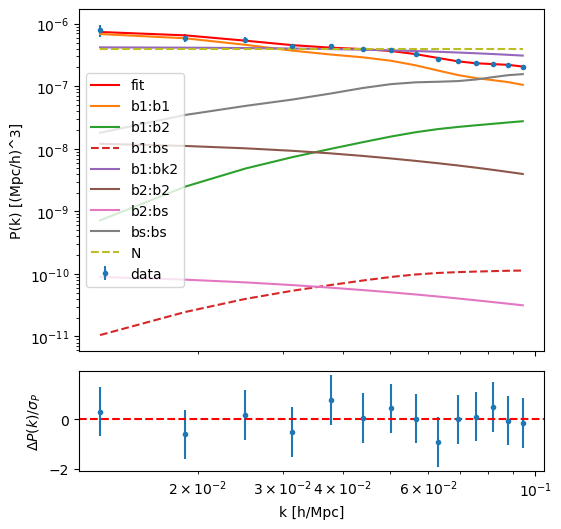

In [49]:
b_bf, b_cov = fit_pk(snpk, snpk.pks['pressure_pressure'], snpk.epks['pressure_pressure'], kmax=0.1, kmin=0.01, nl = True)[:2]

#### Comparing Fits

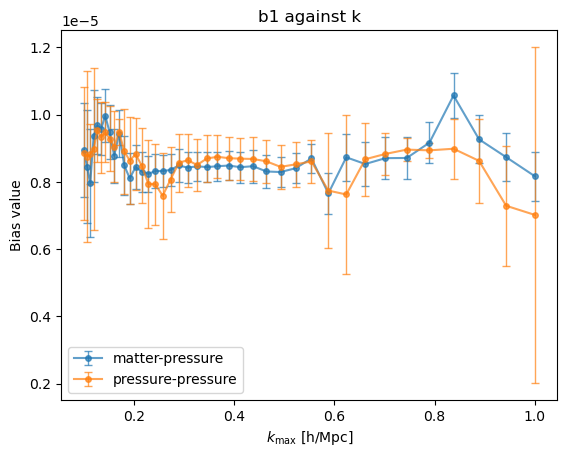

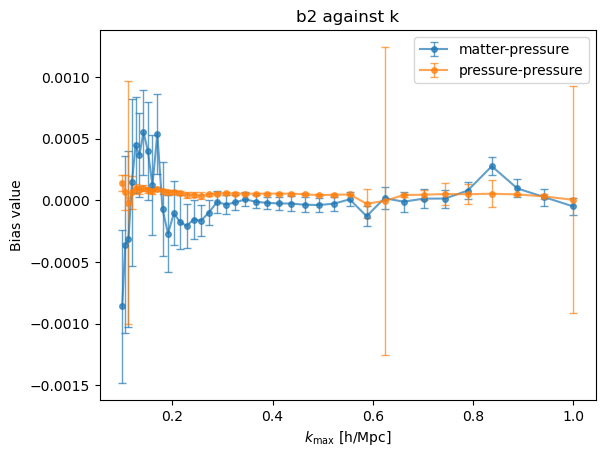

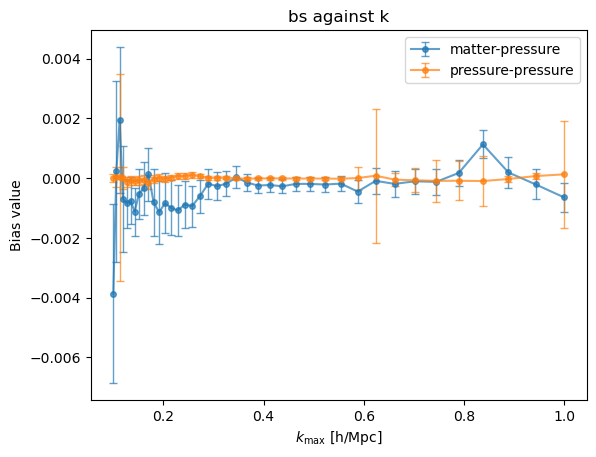

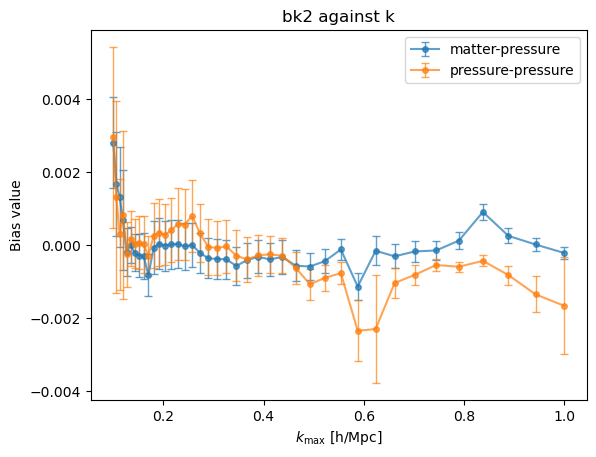

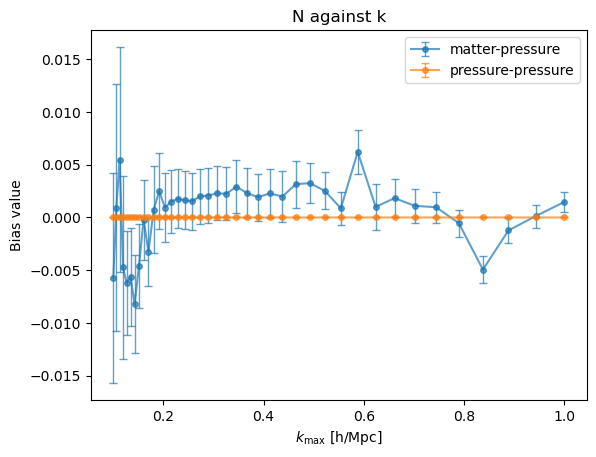

In [50]:
# Set kmaxes
kmaxes = np.geomspace(0.1, 1, 40)
coefficient_plotter(snpk, kmaxes, which = None)

### PlanckNu0p24Fix

In [51]:
# Set a base snapshot
snpk = SnapPk('PlanckNu0p24Fix', 67, kmax=10)
# And the right cosmological parameters
cosmo = ccl.Cosmology(h=0.673, Omega_b=0.0494, Omega_c=0.316-0.0494, n_s=0.966, sigma8=0.769)
ept = ccl.nl_pt.EulerianPTCalculator(with_NC=True, sub_lowk=False, b1_pk_kind='pt', bk2_pk_kind='linear')
ept.update_ingredients(cosmo)
pairs = ['b1:b1', 'b1:b2', 'b1:bs', 'b1:bk2', 'b2:b2', 'b2:bs', 'bs:bs']
pk2d_templates = {pair: ept.get_pk2d_template(pair) for pair in pairs}

#### Fitting Matter-Pressure

Fit results: b1=7.794e-06, b2=-5.866e-04, bs=-2.945e-03, bk2=0.0021, N=-4.881e-03, chi2/ndof=0.11
Fit results: b1=7.794e-06, b2=-5.866e-04, bs=-2.945e-03, bk2=2.102e-03, N=-4.881e-03, chi2/ndof=0.11


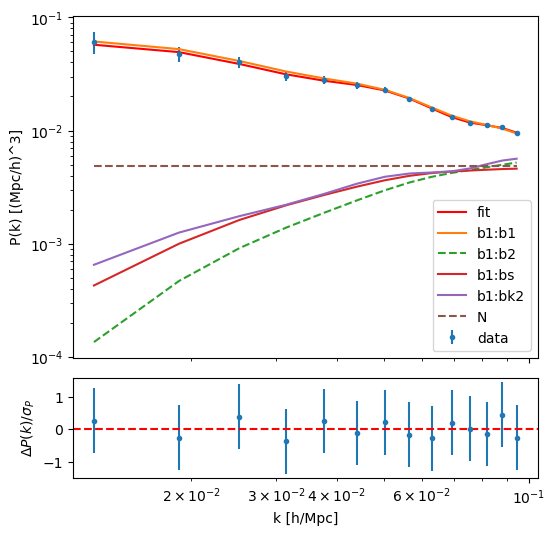

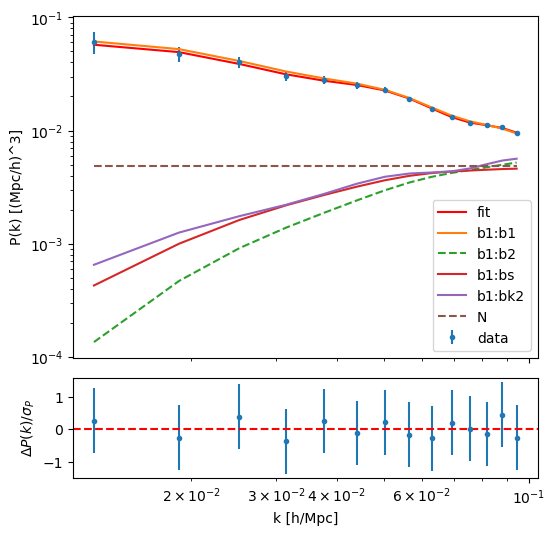

In [52]:
b_bf_ana, b_cov_ana = fit_pk_analytic(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]
b_bf, b_cov = fit_pk(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]

#### Fitting Pressure-Pressure

Fit results: b1=7.588e-06, b2=1.194e-04, bs=-6.388e-06, bk2=2.157e-03, N=-2.175e-07, chi2/ndof=0.27
[ 7.58801001e-06  1.19440639e-04 -6.38788505e-06  2.15714184e-03
 -2.17475087e-07]


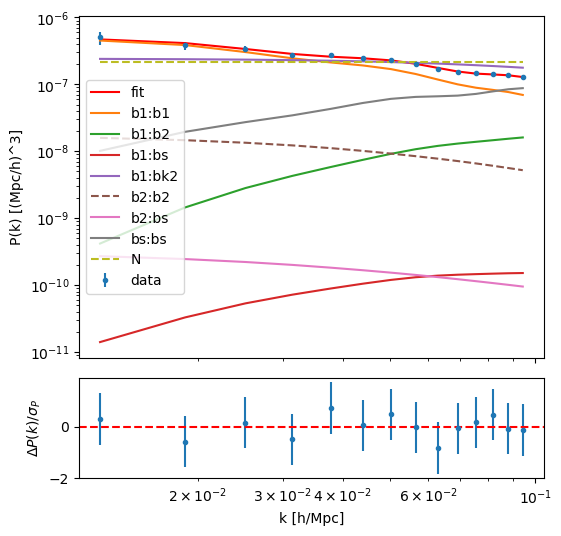

In [53]:
b_bf, b_cov = fit_pk(snpk, snpk.pks['pressure_pressure'], snpk.epks['pressure_pressure'], kmax=0.1, kmin=0.01, nl = True)[:2]

#### Comparing Fits

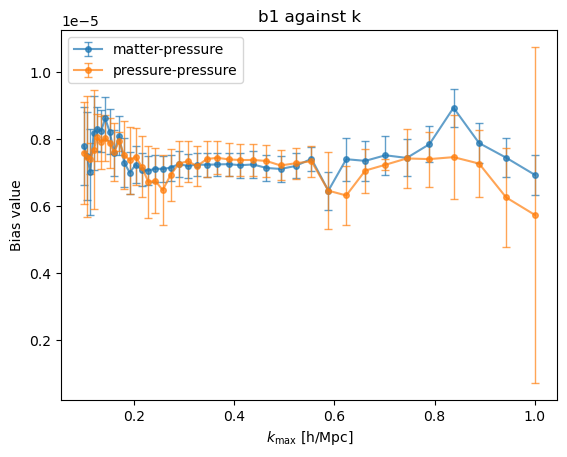

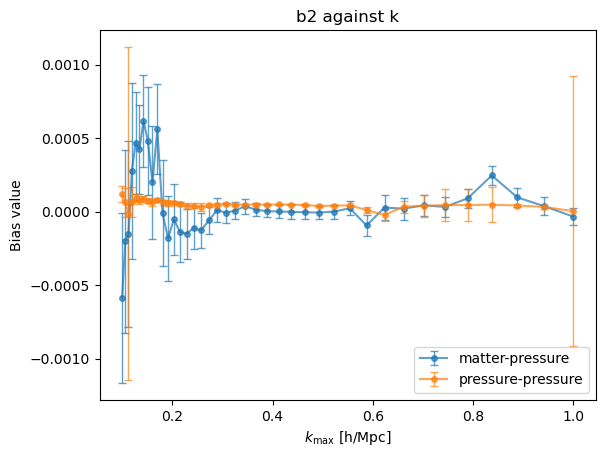

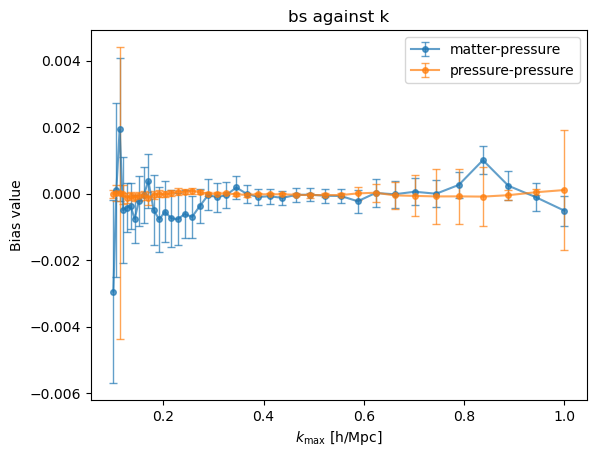

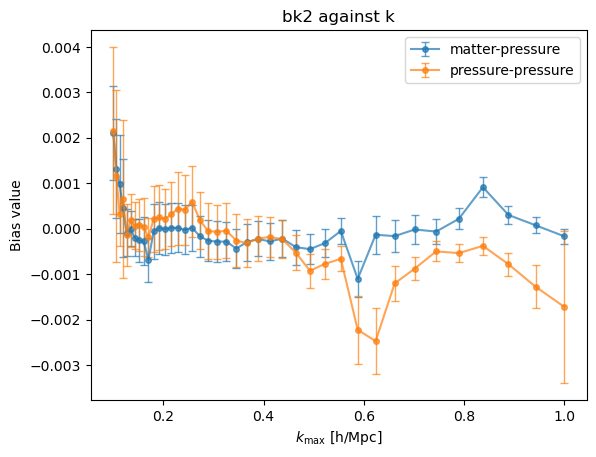

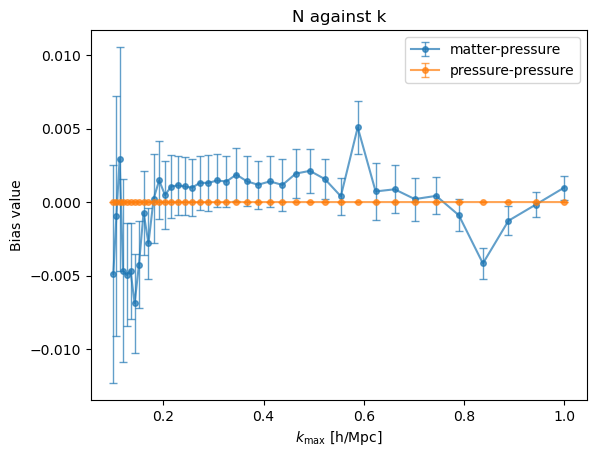

In [54]:
# Set kmaxes
kmaxes = np.geomspace(0.1, 1, 40)
coefficient_plotter(snpk, kmaxes, which = None)

### PlanckNu0p24Var

In [55]:
# Set a base snapshot
snpk = SnapPk('PlanckNu0p24Var', 67, kmax=10)
# And the right cosmological parameters
cosmo = ccl.Cosmology(h=0.662, Omega_b=0.0510, Omega_c=	0.328-0.0510, n_s=0.968, sigma8=0.772)
ept = ccl.nl_pt.EulerianPTCalculator(with_NC=True, sub_lowk=False, b1_pk_kind='pt', bk2_pk_kind='linear')
ept.update_ingredients(cosmo)
pairs = ['b1:b1', 'b1:b2', 'b1:bs', 'b1:bk2', 'b2:b2', 'b2:bs', 'bs:bs']
pk2d_templates = {pair: ept.get_pk2d_template(pair) for pair in pairs}

#### Fitting Matter-Pressure

Fit results: b1=8.159e-06, b2=-6.467e-04, bs=-3.113e-03, bk2=0.00222, N=-4.937e-03, chi2/ndof=0.11
Fit results: b1=8.159e-06, b2=-6.467e-04, bs=-3.113e-03, bk2=2.221e-03, N=-4.937e-03, chi2/ndof=0.11


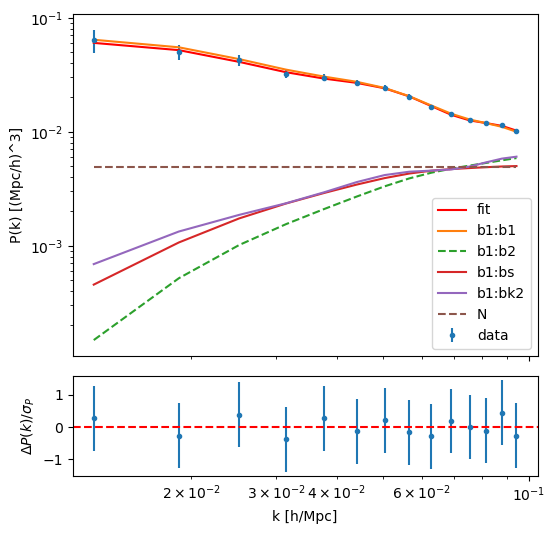

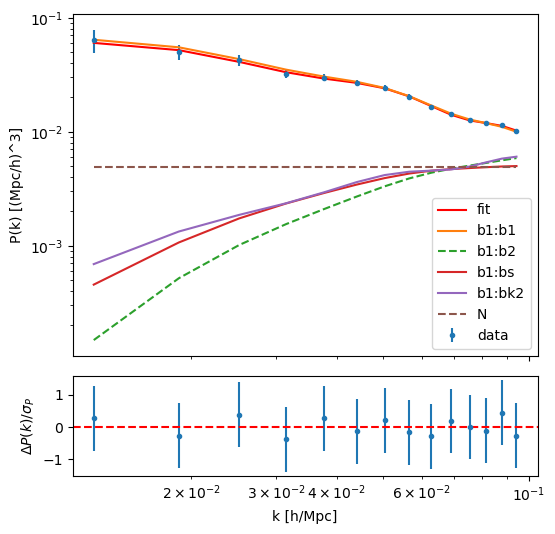

In [56]:
b_bf_ana, b_cov_ana = fit_pk_analytic(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]
b_bf, b_cov = fit_pk(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]

#### Fitting Pressure-Pressure

Fit results: b1=8.036e-06, b2=1.287e-04, bs=-1.199e-05, bk2=2.167e-03, N=-2.504e-07, chi2/ndof=0.29
[ 8.03551106e-06  1.28694968e-04 -1.19861301e-05  2.16711983e-03
 -2.50376771e-07]


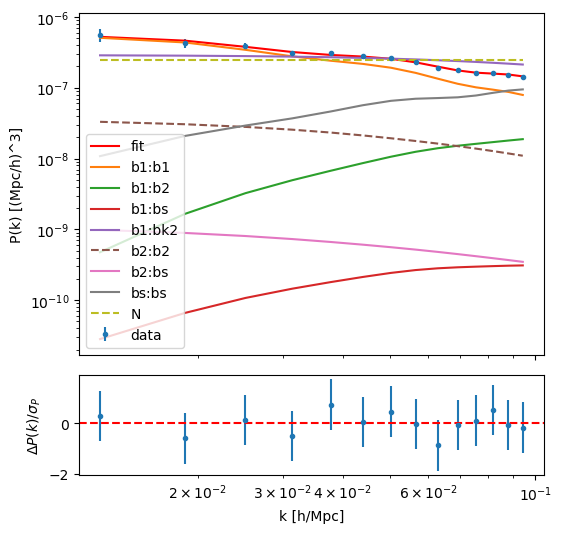

In [57]:
b_bf, b_cov = fit_pk(snpk, snpk.pks['pressure_pressure'], snpk.epks['pressure_pressure'], kmax=0.1, kmin=0.01, nl = True)[:2]

#### Comparing Fits

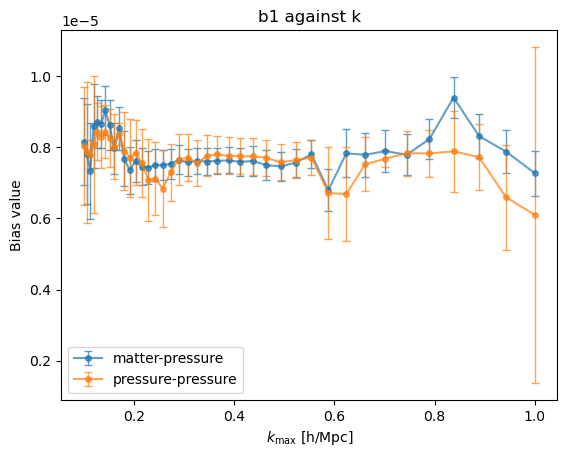

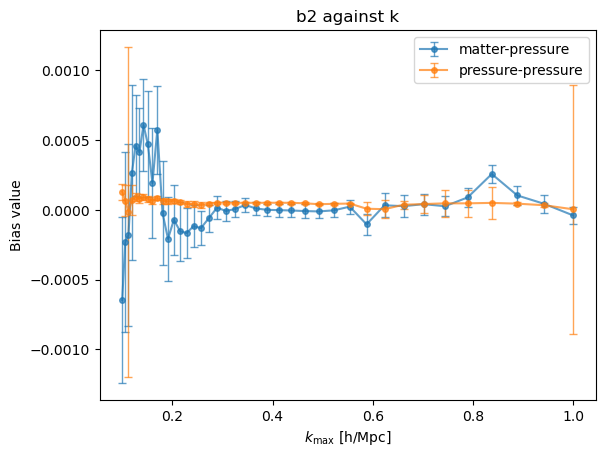

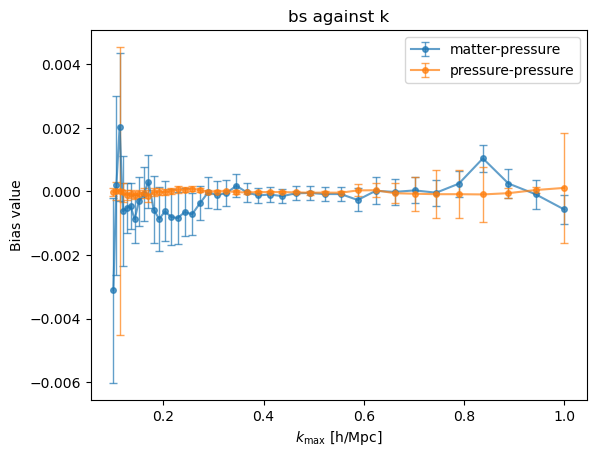

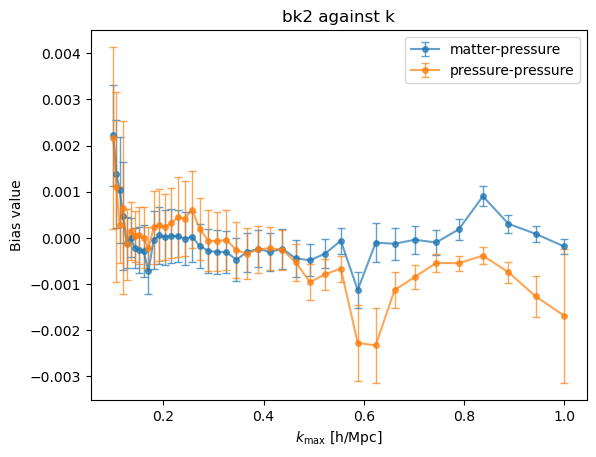

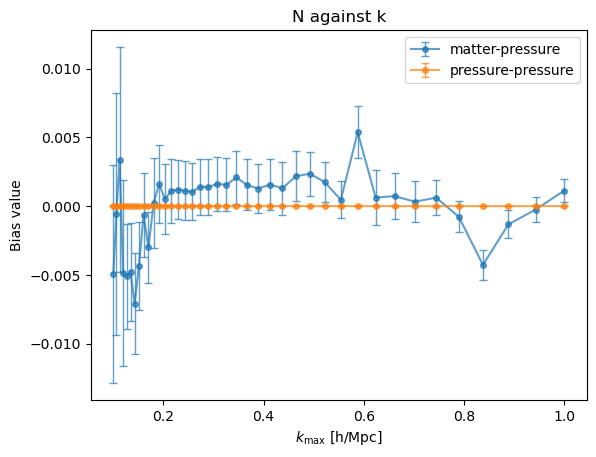

In [58]:
# Set kmaxes
kmaxes = np.geomspace(0.1, 1, 40)
coefficient_plotter(snpk, kmaxes, which = None)

### PlanckNu0p48Fix

In [59]:
# Set a base snapshot
snpk = SnapPk('PlanckNu0p48Fix', 67, kmax=10)
# And the right cosmological parameters
cosmo = ccl.Cosmology(h=0.673, Omega_b=0.0494, Omega_c=0.316-0.0494, n_s=0.966, sigma8=0.709)
ept = ccl.nl_pt.EulerianPTCalculator(with_NC=True, sub_lowk=False, b1_pk_kind='pt', bk2_pk_kind='linear')
ept.update_ingredients(cosmo)
pairs = ['b1:b1', 'b1:b2', 'b1:bs', 'b1:bk2', 'b2:b2', 'b2:bs', 'bs:bs']
pk2d_templates = {pair: ept.get_pk2d_template(pair) for pair in pairs}

#### Fitting Matter-Pressure

Fit results: b1=6.258e-06, b2=-1.469e-04, bs=-1.594e-03, bk2=0.00123, N=-4.067e-03, chi2/ndof=0.11
Fit results: b1=6.258e-06, b2=-1.469e-04, bs=-1.594e-03, bk2=1.228e-03, N=-4.067e-03, chi2/ndof=0.11


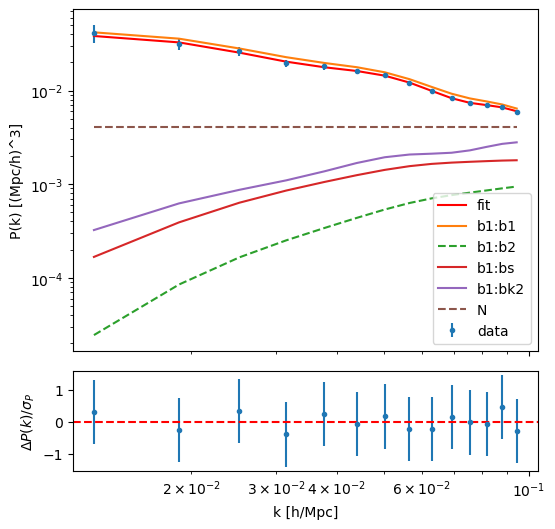

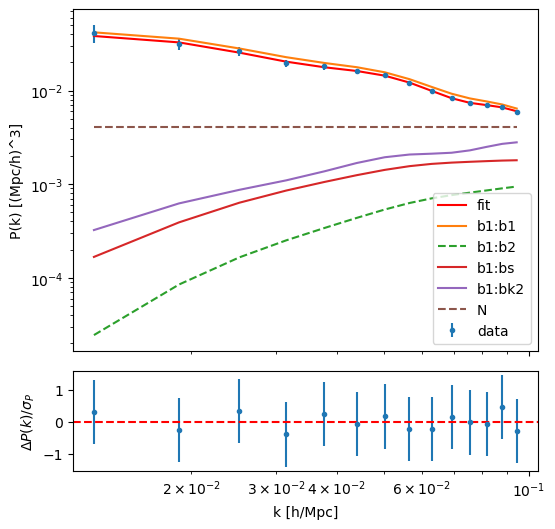

In [60]:
b_bf_ana, b_cov_ana = fit_pk_analytic(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]
b_bf, b_cov = fit_pk(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]

#### Fitting Pressure-Pressure

Fit results: b1=5.797e-06, b2=8.922e-05, bs=-1.705e-05, bk2=1.269e-03, N=-8.094e-08, chi2/ndof=0.26
[ 5.79714257e-06  8.92180239e-05 -1.70524085e-05  1.26934946e-03
 -8.09408816e-08]


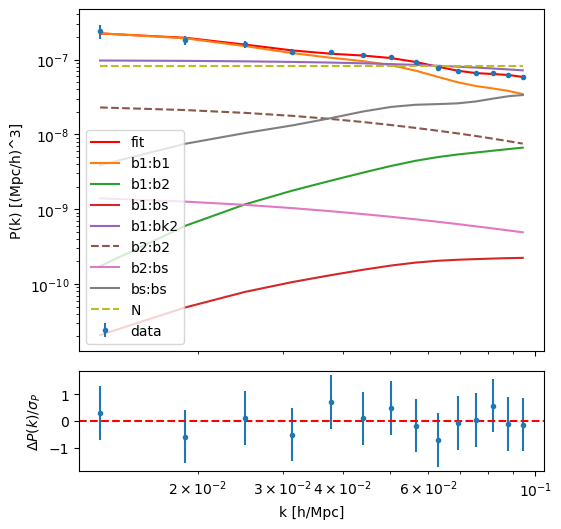

In [61]:
b_bf, b_cov = fit_pk(snpk, snpk.pks['pressure_pressure'], snpk.epks['pressure_pressure'], kmax=0.1, kmin=0.01, nl = True)[:2]

#### Comparing Fits

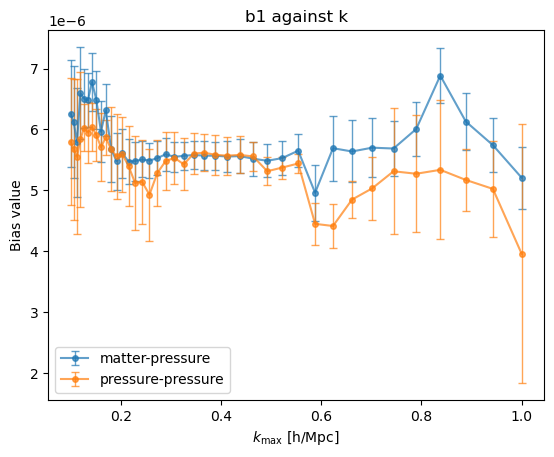

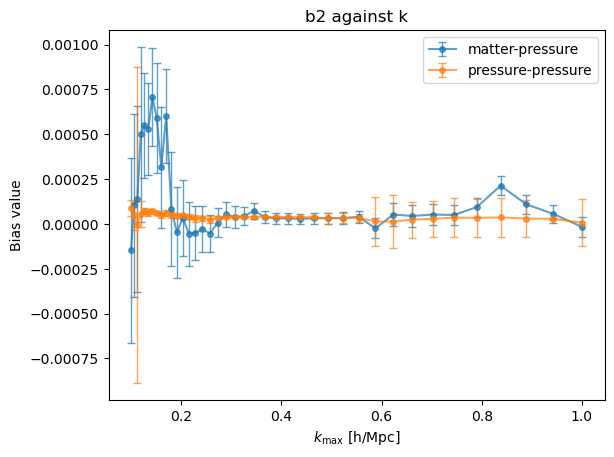

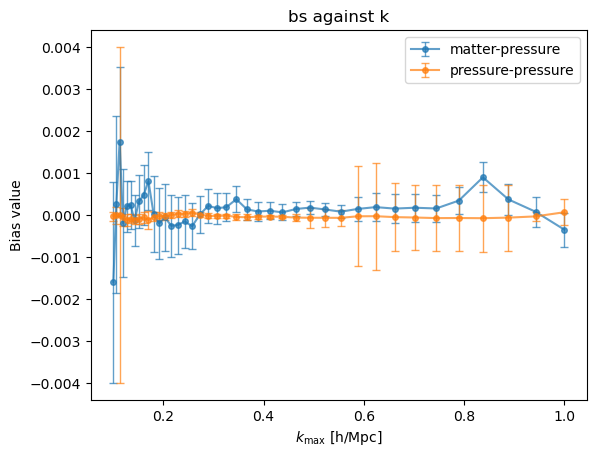

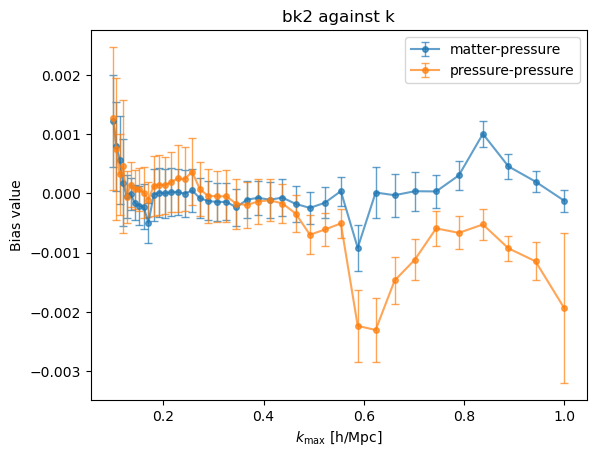

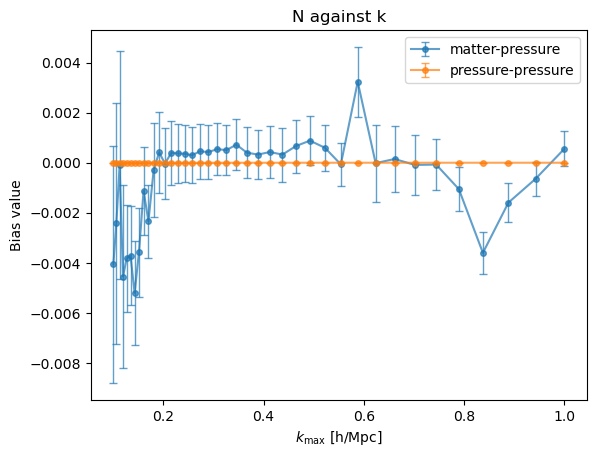

In [62]:
# Set kmaxes
kmaxes = np.geomspace(0.1, 1, 40)
coefficient_plotter(snpk, kmaxes, which = None)

### LS8

In [63]:
# Set a base snapshot
snpk = SnapPk('LS8', 67, kmax=10)
# And the right cosmological parameters
cosmo = ccl.Cosmology(h=0.682, Omega_b=0.0473, Omega_c=0.305-0.0473, n_s=0.965, sigma8=0.760)
ept = ccl.nl_pt.EulerianPTCalculator(with_NC=True, sub_lowk=False, b1_pk_kind='pt', bk2_pk_kind='linear')
ept.update_ingredients(cosmo)
pairs = ['b1:b1', 'b1:b2', 'b1:bs', 'b1:bk2', 'b2:b2', 'b2:bs', 'bs:bs']
pk2d_templates = {pair: ept.get_pk2d_template(pair) for pair in pairs}

#### Fitting Matter-Pressure

Fit results: b1=6.179e-06, b2=-6.240e-04, bs=-2.935e-03, bk2=0.00187, N=-3.620e-03, chi2/ndof=0.09
Fit results: b1=6.179e-06, b2=-6.240e-04, bs=-2.935e-03, bk2=1.875e-03, N=-3.620e-03, chi2/ndof=0.09


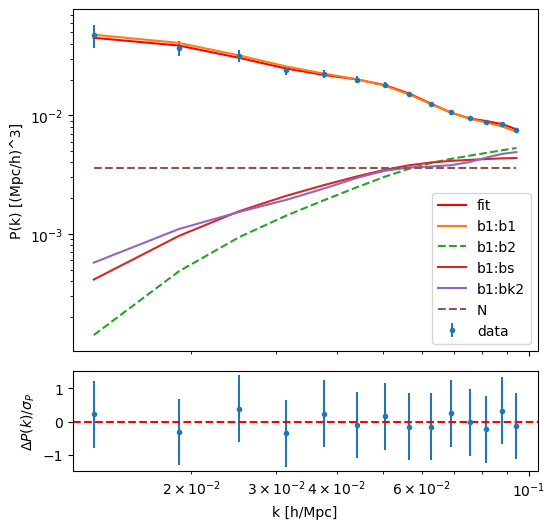

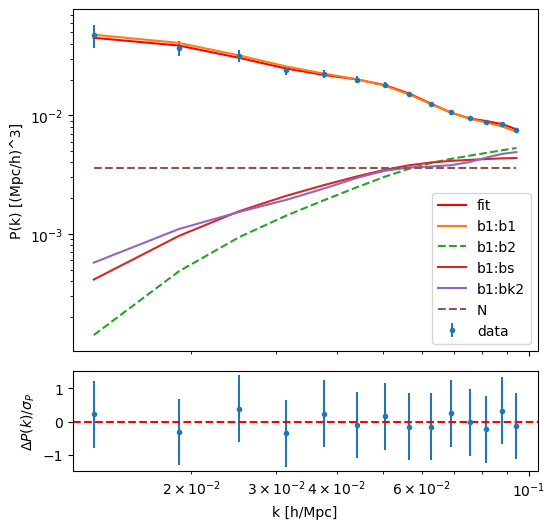

In [64]:
b_bf_ana, b_cov_ana = fit_pk_analytic(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]
b_bf, b_cov = fit_pk(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]

#### Fitting Pressure-Pressure

Fit results: b1=6.004e-06, b2=9.957e-05, bs=8.510e-06, bk2=2.128e-03, N=-1.565e-07, chi2/ndof=0.23
[ 6.00353054e-06  9.95691826e-05  8.50996722e-06  2.12789440e-03
 -1.56545193e-07]


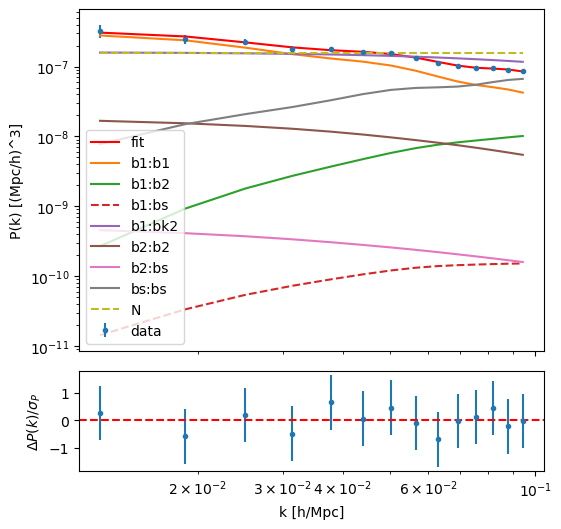

In [65]:
b_bf, b_cov = fit_pk(snpk, snpk.pks['pressure_pressure'], snpk.epks['pressure_pressure'], kmax=0.1, kmin=0.01, nl = True)[:2]

#### Comparing Fits

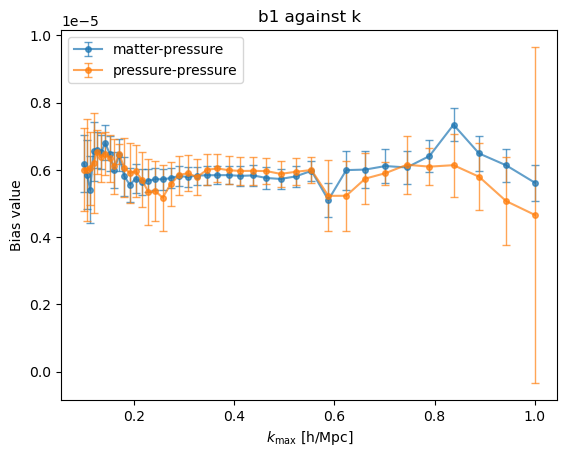

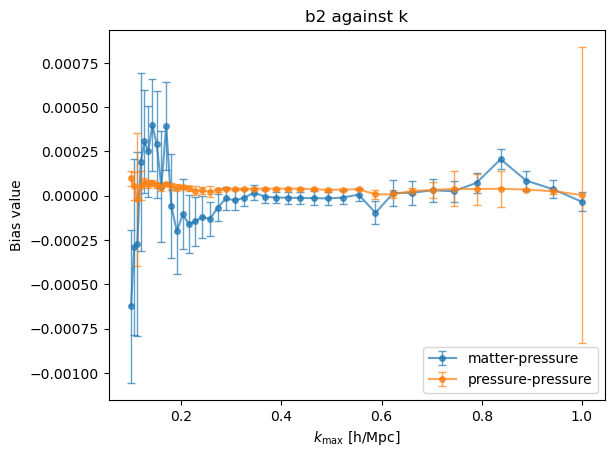

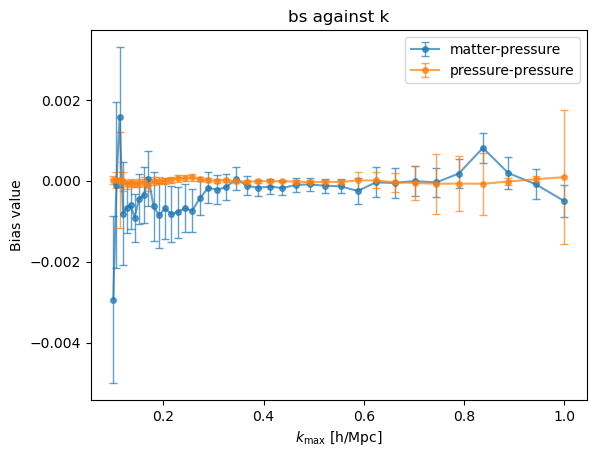

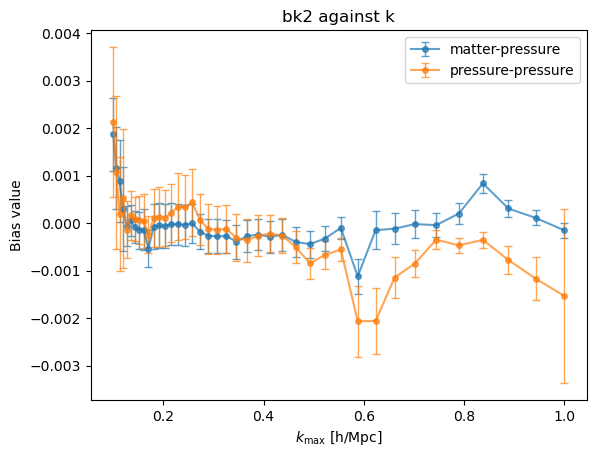

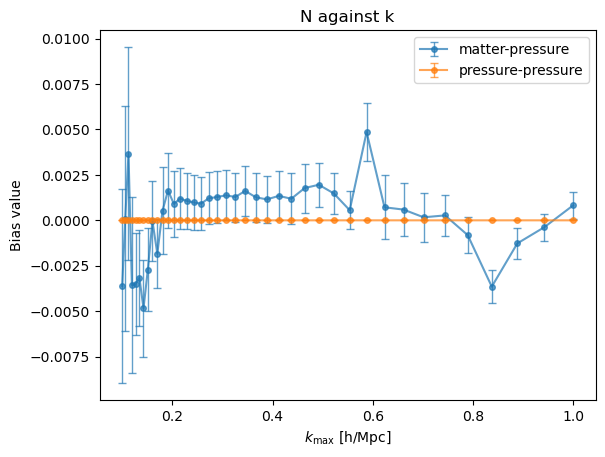

In [66]:
# Set kmaxes
kmaxes = np.geomspace(0.1, 1, 40)
coefficient_plotter(snpk, kmaxes, which = None)

### LS8_fgas-8sigma

In [67]:
# Set a base snapshot
snpk = SnapPk('LS8_fgas-8sigma', 67, kmax=10)
# And the right cosmological parameters
cosmo = ccl.Cosmology(h=0.682, Omega_b=0.0473, Omega_c=0.305-0.0473, n_s=0.965, sigma8=0.760)
ept = ccl.nl_pt.EulerianPTCalculator(with_NC=True, sub_lowk=False, b1_pk_kind='pt', bk2_pk_kind='linear')
ept.update_ingredients(cosmo)
pairs = ['b1:b1', 'b1:b2', 'b1:bs', 'b1:bk2', 'b2:b2', 'b2:bs', 'bs:bs']
pk2d_templates = {pair: ept.get_pk2d_template(pair) for pair in pairs}

#### Fitting Matter-Pressure

Fit results: b1=7.793e-06, b2=-6.858e-04, bs=-3.398e-03, bk2=0.00213, N=-4.414e-03, chi2/ndof=0.07
Fit results: b1=7.793e-06, b2=-6.858e-04, bs=-3.398e-03, bk2=2.129e-03, N=-4.414e-03, chi2/ndof=0.07


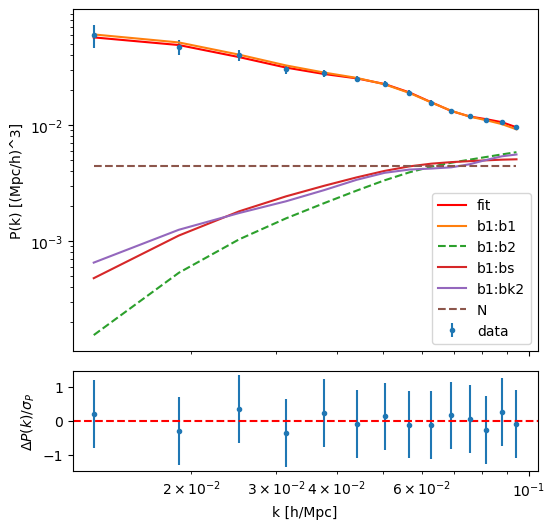

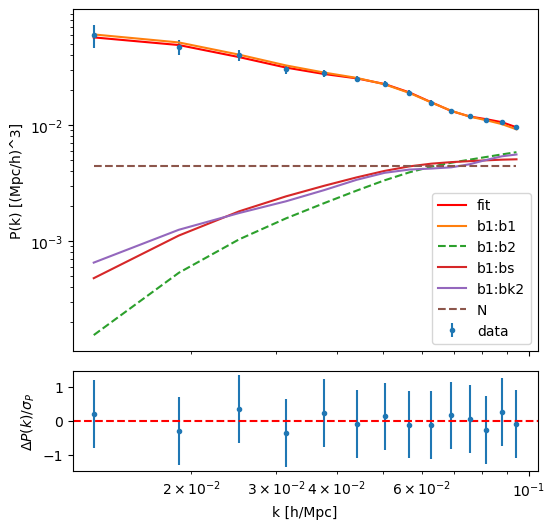

In [68]:
b_bf_ana, b_cov_ana = fit_pk_analytic(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]
b_bf, b_cov = fit_pk(snpk, snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.1, kmin=0.01)[:2]

#### Fitting Pressure-Pressure

Fit results: b1=7.724e-06, b2=1.229e-04, bs=-8.545e-07, bk2=2.375e-03, N=-2.357e-07, chi2/ndof=0.17
[ 7.72397438e-06  1.22901402e-04 -8.54470149e-07  2.37501255e-03
 -2.35704979e-07]


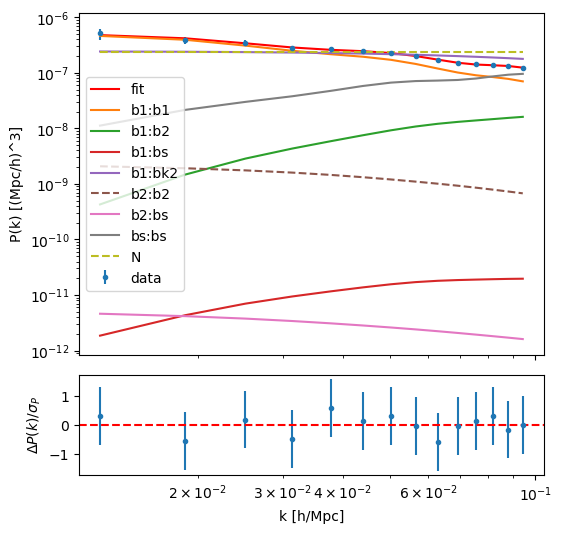

In [69]:
b_bf, b_cov = fit_pk(snpk, snpk.pks['pressure_pressure'], snpk.epks['pressure_pressure'], kmax=0.1, kmin=0.01, nl = True)[:2]

#### Comparing Fits

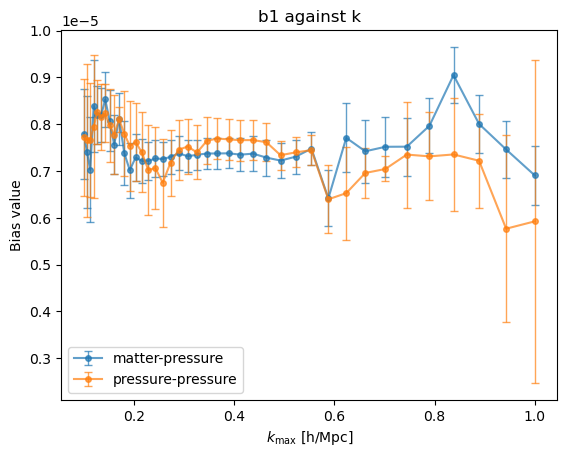

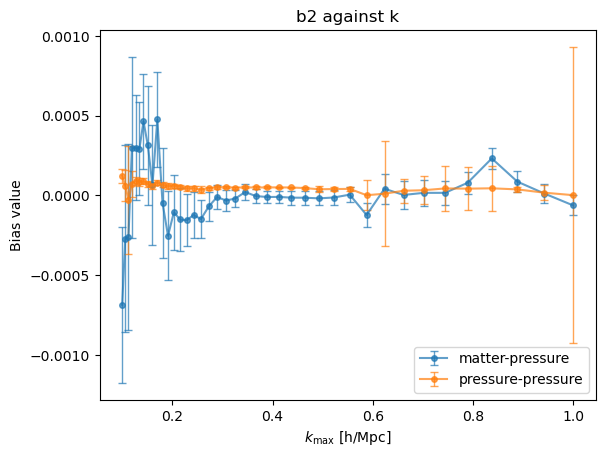

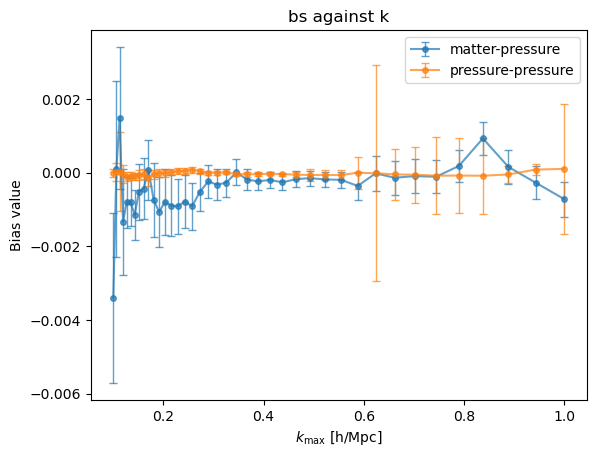

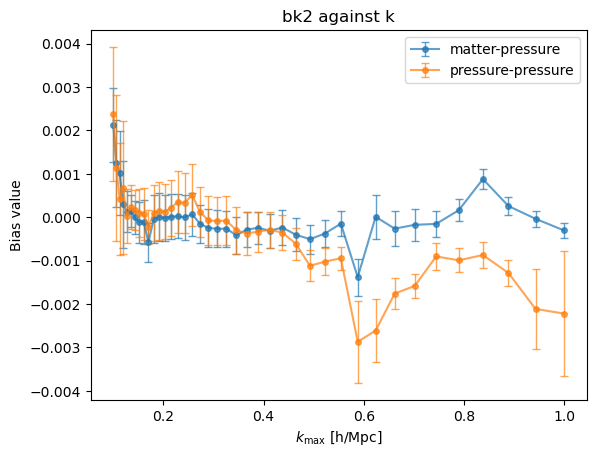

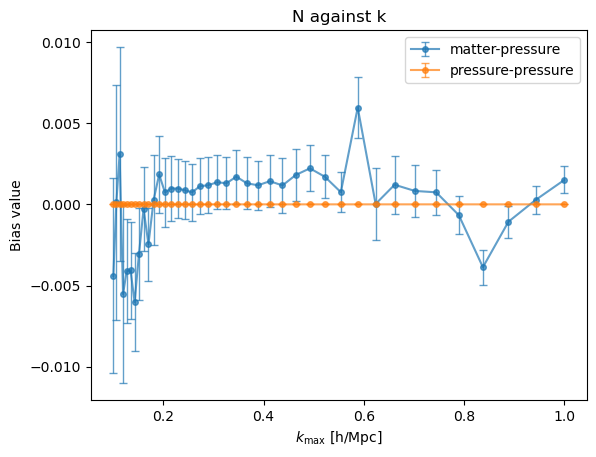

In [70]:
# Set kmaxes
kmaxes = np.geomspace(0.1, 1, 40)
coefficient_plotter(snpk, kmaxes, which = None)